# AI빅데이터전공 20221389 장우혁
# 검색 키워드 : AI 저작권
# 검색 기간 : 2025 03 16 ~ 2026 05 14
## 어디서부터 실행하시면 되는지 적어뒀습니다 형태소분석까지는 내리셔야 합니다 ! 

# 네이버 블로그 크롤링 코드

In [7]:
import datetime
import time
import re
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup as BS
import os

# 1. 설정 및 파일 경로
file_path = r'C:\Users\WHKONG\AI 저작권 여론 분석'
search_query = "AI 저작권"
final_file_name = "네이버블로그_AI저작권_총합본.csv" # 통합 파일명

if not os.path.exists(file_path):
    os.makedirs(file_path)

# 통합 수집용 리스트 (루프 밖에서 초기화)
total_title = []; total_url = []; total_doc = []
total_date = []
total_like = []; total_comment_cnt = []; total_comment_list = []
total_img = []; total_video = []

start_dates = [
    "20250326", "20250402", "20250409", "20250416", "20250423", "20250430", "20250507", "20250514", 
    "20250521", "20250528", "20250604", "20250611", "20250618", "20250625", "20250702", "20250709", 
    "20250716", "20250723", "20250730", "20250806", "20250813", "20250820", "20250827", "20250903", 
    "20250910", "20250917", "20250924", "20251001", "20251008", "20251015", "20251022", "20251029", 
    "20251105", "20251112", "20251119", "20251126", "20251203", "20251210", "20251217", "20251224", 
    "20251231", "20260107", "20260114", "20260121", "20260128", "20260204", "20260211", "20260218", 
    "20260225", "20260304", "20260311", "20260318", "20260325", "20260401", "20260408", "20260415", 
    "20260422", "20260429", "20260506", "20260513"
]

end_dates = [
    "20250401", "20250408", "20250415", "20250422", "20250429", "20250506", "20250513", "20250520", 
    "20250527", "20250603", "20250610", "20250617", "20250624", "20250701", "20250708", "20250715", 
    "20250722", "20250729", "20250805", "20250812", "20250819", "20250826", "20250902", "20250909", 
    "20250916", "20250923", "20250930", "20251007", "20251014", "20251021", "20251028", "20251104", 
    "20251111", "20251118", "20251125", "20251202", "20251209", "20251216", "20251223", "20251230", 
    "20260106", "20260113", "20260120", "20260127", "20260203", "20260210", "20260217", "20260224", 
    "20260303", "20260310", "20260317", "20260324", "20260331", "20260407", "20260414", "20260421", 
    "20260428", "20260505", "20260512", "20260514"
]

driver = webdriver.Chrome()

def doScrollDown(whileSeconds):
    start = datetime.datetime.now()
    end = start + datetime.timedelta(seconds=whileSeconds)
    while True:
        driver.execute_script('window.scrollTo(0, document.body.scrollHeight);')
        time.sleep(1.2)
        if datetime.datetime.now() > end:
            break

# 2. 루프 시작
for s_date, e_date in zip(start_dates, end_dates):
    print(f"--- {s_date} ~ {e_date} 구간 수집 시작 ---")
    
    url = f"https://search.naver.com/search.naver?ssc=tab.blog.all&query={search_query}&sm=tab_opt&nso=so%3Ar%2Cp%3Afrom{s_date}to{e_date}"
    driver.get(url)
    time.sleep(2)

    doScrollDown(70) # 우혁 님 원래 설정인 70초 유지

    selector = ".sds-comps-text.sds-comps-text-type-headline1"
    titles = driver.find_elements(By.CSS_SELECTOR, selector)
    
    current_urls = []
    current_titles = []
    
    for element in titles:
        try:
            title_text = element.text.strip()
            if element.tag_name == 'span':
                u = element.find_element(By.XPATH, '..').get_attribute('href')
            else:
                u = element.get_attribute('href')
            
            if u and "blog.naver.com" in u: # 외부 링크 필터링
                current_urls.append(u)
                current_titles.append(title_text)
        except:
            continue

    print(f"[{s_date}] 유효한 네이버 블로그 {len(current_urls)}개 상세 수집 중...")

    # 3. 상세 페이지 크롤링
    for idx, url_path in enumerate(current_urls):
        try:
            driver.execute_script(f"window.open('{url_path}')")
            driver.switch_to.window(driver.window_handles[-1])
            time.sleep(2)

            WebDriverWait(driver, 10).until(EC.frame_to_be_available_and_switch_to_it("mainFrame"))
            soup = BS(driver.page_source, 'html.parser')
            
            # --- 데이터 추출 ---
            # 작성 날짜
            try:
                date_el = soup.select_one('.se_publishDate, .publish_date, .se-date')
                post_date = date_el.get_text().strip() if date_el else "날짜 확인 불가"
            except: post_date = "날짜 오류"

            # 좋아요
            try:
                like_el = driver.find_elements(By.CSS_SELECTOR, 'span.u_likeit_text._count.num, em.u_cnt._count, span._count')
                l_val = '0'
                for el in like_el:
                    if el.text.strip():
                        l_val = re.sub(r'[^0-9]', '', el.text.strip()); break
            except: l_val = '0'

            # 댓글수
            try:
                c_el = driver.find_elements(By.CSS_SELECTOR, "#commentCount, em.em_num, span.u_cbox_count")
                c_val = '0'
                for el in c_el:
                    tmp = el.text.strip()
                    if tmp:
                        tmp = re.sub(r'[^0-9]', '', tmp)
                        if tmp: c_val = tmp; break
            except: c_val = '0'

            # 본문/이미지/영상
            content_box = soup.select_one('.se-main-container')
            txt = content_box.get_text(separator=' ', strip=True) if content_box else "본문 없음"
            img_n = len(soup.select('img.se-image-resource'))
            vid_n = len(soup.select('.se-component-video'))

            # 댓글내용
            try:
                comment_btn = driver.find_element(By.CSS_SELECTOR, "#commentCount, a.btn_comment")
                driver.execute_script("arguments[0].click();", comment_btn)
                time.sleep(1.5)
                comments = driver.find_elements(By.CLASS_NAME, 'u_cbox_contents')
                cmt_txt = "\n".join([cmt.text for cmt in comments]) if comments else "댓글 없음"
            except: cmt_txt = 'null'

            # 통합 리스트에 데이터 추가
            total_title.append(current_titles[idx])
            total_url.append(url_path)
            total_doc.append(txt)
            total_date.append(post_date)
            total_like.append(l_val)
            total_comment_cnt.append(c_val)
            total_comment_list.append(cmt_txt)
            total_img.append(img_n)
            total_video.append(vid_n)

        except Exception as e:
            print(f"오류 ({url_path}): {e}")
            # 오류 시에도 행 개수 맞추기 위해 더미 데이터 삽입
            total_title.append(current_titles[idx]); total_url.append(url_path)
            total_doc.append("오류"); total_date.append("오류")
            total_like.append("0"); total_comment_cnt.append("0")
            total_comment_list.append("null"); total_img.append(0); total_video.append(0)
        
        finally:
            if len(driver.window_handles) > 1:
                driver.close()
                driver.switch_to.window(driver.window_handles[0])

    # 중간 중간 저장을 통해 데이터 유실 방지 (루프 한 번 끝날 때마다 덮어쓰기 저장)
    df_temp = pd.DataFrame({
        '제목': total_title, '작성날짜': total_date, '링크': total_url, '본문': total_doc,
        '좋아요수': total_like, '댓글수': total_comment_cnt, '댓글내용': total_comment_list,
        '이미지수': total_img, '영상수': total_video, '크롤링 위치': '네이버 블로그'
    })
    df_temp.to_csv(os.path.join(file_path, final_file_name), index=False, encoding='utf-8-sig')
    print(f">>> 현재까지 총 {len(total_title)}건 수집 및 '{final_file_name}' 갱신 완료")

print(f"--- 모든 기간 수집 완료! 총 {len(total_title)}건이 저장되었습니다. ---")
driver.quit()

--- 20250326 ~ 20250401 구간 수집 시작 ---
[20250326] 유효한 네이버 블로그 926개 상세 수집 중...
>>> 현재까지 총 926건 수집 및 '네이버블로그_AI저작권_총합본.csv' 갱신 완료
--- 20250402 ~ 20250408 구간 수집 시작 ---
[20250402] 유효한 네이버 블로그 903개 상세 수집 중...
>>> 현재까지 총 1829건 수집 및 '네이버블로그_AI저작권_총합본.csv' 갱신 완료
--- 20250409 ~ 20250415 구간 수집 시작 ---
[20250409] 유효한 네이버 블로그 927개 상세 수집 중...
>>> 현재까지 총 2756건 수집 및 '네이버블로그_AI저작권_총합본.csv' 갱신 완료
--- 20250416 ~ 20250422 구간 수집 시작 ---
[20250416] 유효한 네이버 블로그 931개 상세 수집 중...
>>> 현재까지 총 3687건 수집 및 '네이버블로그_AI저작권_총합본.csv' 갱신 완료
--- 20250423 ~ 20250429 구간 수집 시작 ---
[20250423] 유효한 네이버 블로그 934개 상세 수집 중...
>>> 현재까지 총 4621건 수집 및 '네이버블로그_AI저작권_총합본.csv' 갱신 완료
--- 20250430 ~ 20250506 구간 수집 시작 ---
[20250430] 유효한 네이버 블로그 960개 상세 수집 중...
>>> 현재까지 총 5581건 수집 및 '네이버블로그_AI저작권_총합본.csv' 갱신 완료
--- 20250507 ~ 20250513 구간 수집 시작 ---
[20250507] 유효한 네이버 블로그 902개 상세 수집 중...
>>> 현재까지 총 6483건 수집 및 '네이버블로그_AI저작권_총합본.csv' 갱신 완료
--- 20250514 ~ 20250520 구간 수집 시작 ---
[20250514] 유효한 네이버 블로그 852개 상세 수집 중...
>>> 현재까지 총 7335건 수집 및 '네이버블로그_AI저작권_

In [17]:
import pandas as pd
import os

# 1. 파일 경로 설정
file_path = r'C:\Users\WHKONG\AI 저작권 여론 분석'
file_name = "네이버블로그_AI저작권_총합본.csv"
full_path = os.path.join(file_path, file_name)

# 2. 파일이 존재하는지 확인 후 읽기
if os.path.exists(full_path):
    # 인코딩은 크롤링 코드와 맞춰서 utf-8-sig로 설정
    df = pd.read_csv(full_path, encoding='utf-8-sig')
    
    print(f"=== 데이터 로드 완료 ===")
    print(f"전체 수집 건수: {len(df)}건")
    print(f"컬럼 목록: {list(df.columns)}\n")
    
    # 3. 데이터프레임 출력 옵션 설정 (데이터가 잘리지 않게 조정)
    pd.set_option('display.max_columns', None)        # 모든 컬럼 출력
    pd.set_option('display.max_colwidth', 50)         # 본문 내용 너무 길면 50자까지만 자르기
    pd.set_option('display.width', 1000)              # 콘솔 출력 가로 폭 확대
    
    # 4. 상위 100개 데이터 확인
    
    
    # 만약 본문이나 다른 컬럼까지 다 보고 싶다면 아래 주석을 해제하세요.
    preview_df = df.head(100)
    
    # 출력
    print("=== 상위 100개 데이터 미리보기 ===")
    display(preview_df) # Jupyter Notebook / VS Code용 (콘솔 환경이면 print(preview_df) 사용)

else:
    print(f"🚨 파일을 찾을 수 없습니다. 경로를 확인해 주세요.\n입력된 경로: {full_path}")

=== 데이터 로드 완료 ===
전체 수집 건수: 52830건
컬럼 목록: ['제목', '작성날짜', '링크', '본문', '좋아요수', '댓글수', '댓글내용', '이미지수', '영상수', '크롤링 위치']

=== 상위 100개 데이터 미리보기 ===


,제목,작성날짜,링크,본문,좋아요수,댓글수,댓글내용,이미지수,영상수,크롤링 위치
0,인공지능 생성 콘텐츠에 적용되는 저작권 기준,2025. 3. 30. 23:40,https://blog.naver.com/nft5fpgy4d4q6/223813504810,인공지능 생성 콘텐츠에 적용되는 저작권 기준 인공지능 기술이 발전하면서 콘텐츠 제작...,0,0,댓글 없음,1,0,네이버 블로그
1,"오픈AI, ‘지브리풍’ 이미지 열풍에 GPU 녹아내려, AI사용 제한에 저작권 침해...",2025. 3. 31. 20:03,https://blog.naver.com/lkyj8ch/223816504543,-.오픈AI가 최근 출시한 ‘쳇GPT-4o 이미지제네레이션’ 모델의 지브리 스타일이...,0,0,댓글 없음,8,0,네이버 블로그
2,챗지피티로 지브리 스타일 이미지 만들기 AI 창작 소셜미디어 인기 디지털아트 문제,2025. 3. 31. 11:05,https://blog.naver.com/ohayo11/223815849053,챗지피티로 지브리 스타일 이미지 만들기 ​ 최근 챗지피티와 같은 AI 기술이 예술 ...,5,2,사과향님\n블로그 포스팅 몇몇개 읽어보고 갑니다 ㅋ\n오늘도 활기찬 날 되시길 바랍...,3,0,네이버 블로그
3,AI 그림 혁명인가 저작권 침해인가? 챗GPT 지브리 논란의 모든 것,2025. 3. 31. 9:00,https://blog.naver.com/borastart/223814887124,챗GPT 지브리 열풍과 미술의 새로운 가능성 저작권 논란 너머 창조적 진화 챗GPT...,0,0,댓글 없음,6,0,네이버 블로그
4,"음악저작물 저작권등록 신청, AI 산출물의 저작권 등록 가능여부",2025. 4. 1. 18:18,https://blog.naver.com/ch73037/223817766781,저작권등록 대행 지안행정사사무소입니다. ​ 올초부터 여러건의 창작물을 보유하고 계신...,18,0,NaN,2,0,네이버 블로그
...,...,...,...,...,...,...,...,...,...,...
95,지브리AI 무료 생성법 챗GPT로 1분,2025. 3. 31. 11:36,https://blog.naver.com/101lab_/223815889094,"요즘 SNS 보셨나요? 인스타 스토리, 틱톡, 유튜브 쇼츠에 지브리 감성 그림이 쏟...",14,3,"지브리 애니를 엄청 좋아하는데, 요즘 gpt 때문에 많이 접하게 되네요^^\n안녕하...",8,0,네이버 블로그
96,지브리·디즈니 스타일 챗GPT 이미지 생성 예쁘지만 저작권 침해일까?,2025. 3. 29. 11:59,https://blog.naver.com/50-2ndchance/223813881731,지브리 스타일 챗GPT 이미지 생성 어머 이건 나야? ​ 지브리 주인공 된 우리 가...,39,17,잘봤어요. 좋으네요. 멋지네요\n와!!정말 잼있네요?\n여러가지 스타일로 다 만들어...,10,0,네이버 블로그
97,[현자AI와의 대담] #11. AGI가 흔들어 놓은 창작의 경계 - 지브리 스타일 논쟁,2025. 3. 31. 16:20,https://blog.naver.com/blackdew7/223816248623,"디지털 시대의 저작권과 창작 ​ 나: 요즘 들어 저작권 얘기가 자꾸 나오는데, 특히...",9,0,댓글 없음,1,0,네이버 블로그
98,저작권이 있는 자료로 AI 훈련시킨 경우 - 공정이용?,2025. 3. 31. 15:01,https://blog.naver.com/yoonbyun/223816138134,"​ ​ ​ ​ 안녕하세요. 잘 아는 변리사 윤혜진입니다. ​ 2025년 2월, 저작...",3,0,댓글 없음,1,0,네이버 블로그


네이버 카페 크롤링 코드

In [35]:
import datetime
import time
import re
import pandas as pd
import os
from pathlib import Path
from urllib.parse import quote

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import SessionNotCreatedException
from bs4 import BeautifulSoup as BS

# ========== 설정 ==========
file_path = r"C:\Users\WHKONG\AI 저작권 여론 분석"
search_query = "AI 저작권"
final_file_name = "네이버카페_AI저작권_총합본.csv"

USE_PERSISTENT_CHROME_PROFILE = True
CHROME_PROFILE_DIR = Path(file_path) / "_selenium_chrome_profile"
MANUAL_LOGIN_AT_START = True
SKIP_MANUAL_LOGIN = False

if not os.path.exists(file_path):
    os.makedirs(file_path)

total_title = []
total_url = []
total_doc = []
total_date = []
total_like = []
total_comment_cnt = []
total_comment_list = []
total_img = []
total_video = []

start_dates = [
    "20250326", "20250402", "20250409", "20250416", "20250423", "20250430", "20250507", "20250514",
    "20250521", "20250528", "20250604", "20250611", "20250618", "20250625", "20250702", "20250709",
    "20250716", "20250723", "20250730", "20250806", "20250813", "20250820", "20250827", "20250903",
    "20250910", "20250917", "20250924", "20251001", "20251008", "20251015", "20251022", "20251029",
    "20251105", "20251112", "20251119", "20251126", "20251203", "20251210", "20251217", "20251224",
    "20251231", "20260107", "20260114", "20260121", "20260128", "20260204", "20260211", "20260218",
    "20260225", "20260304", "20260311", "20260318", "20260325", "20260401", "20260408", "20260415",
    "20260422", "20260429", "20260506", "20260513",
]

end_dates = [
    "20250401", "20250408", "20250415", "20250422", "20250429", "20250506", "20250513", "20250520",
    "20250527", "20250603", "20250610", "20250617", "20250624", "20250701", "20250708", "20250715",
    "20250722", "20250729", "20250805", "20250812", "20250819", "20250826", "20250902", "20250909",
    "20250916", "20250923", "20250930", "20251007", "20251014", "20251021", "20251028", "20251104",
    "20251111", "20251118", "20251125", "20251202", "20251209", "20251216", "20251223", "20251230",
    "20260106", "20260113", "20260120", "20260127", "20260203", "20260210", "20260217", "20260224",
    "20260303", "20260310", "20260317", "20260324", "20260331", "20260407", "20260414", "20260421",
    "20260428", "20260505", "20260512", "20260514",
]

CAFE_URL_PATTERN = re.compile(r"https?://cafe\.naver\.com/[^/?#]+/\d+")


def create_chrome_driver():
    CHROME_PROFILE_DIR.mkdir(parents=True, exist_ok=True)
    attempts = [(CHROME_PROFILE_DIR, 9222), (CHROME_PROFILE_DIR, 9333), (None, 9555)]
    last_exc = None
    for profile_dir, port in attempts:
        opts = Options()
        opts.add_argument("--disable-dev-shm-usage")
        opts.add_argument("--disable-gpu")
        opts.add_argument("--no-first-run")
        opts.add_argument(f"--remote-debugging-port={port}")
        if profile_dir:
            opts.add_argument(f"--user-data-dir={Path(profile_dir).resolve()}")
            opts.add_argument("--profile-directory=Default")
        try:
            return webdriver.Chrome(options=opts)
        except SessionNotCreatedException as exc:
            last_exc = exc
            time.sleep(2)
    raise RuntimeError(f"Chrome 시작 실패: {last_exc}")


def do_scroll_down(driver, seconds):
    end = datetime.datetime.now() + datetime.timedelta(seconds=seconds)
    while datetime.datetime.now() < end:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1.2)


def dismiss_alert_if_any(driver):
    try:
        driver.switch_to.alert.accept()
    except Exception:
        pass


def collect_cafe_search_items(driver):
    urls, titles, seen = [], [], set()
    for el in driver.find_elements(By.CSS_SELECTOR, "a.title_link"):
        try:
            title_text = el.text.strip()
            href = (el.get_attribute("href") or "").strip()
            m = CAFE_URL_PATTERN.search(href)
            if not title_text or not m:
                continue
            url = m.group(0)
            if url in seen:
                continue
            seen.add(url)
            urls.append(url)
            titles.append(title_text)
        except Exception:
            continue
    if urls:
        return titles, urls
    soup = BS(driver.page_source, "html.parser")
    for anchor in soup.select("a[href]"):
        href = (anchor.get("href") or "").strip().replace("&amp;", "&")
        m = CAFE_URL_PATTERN.search(href)
        if not m:
            continue
        url = m.group(0)
        if url in seen:
            continue
        title_text = anchor.get_text(" ", strip=True)
        if not title_text:
            continue
        seen.add(url)
        urls.append(url)
        titles.append(title_text)
    return titles, urls


driver = create_chrome_driver()

if MANUAL_LOGIN_AT_START and not SKIP_MANUAL_LOGIN:
    print("=" * 60)
    print("[수동 로그인] 크롤링 전 네이버 로그인 (선택)")
    print("  로그인 후 Enter / 건너뛰기: s + Enter")
    print("=" * 60)
    driver.get("https://nid.naver.com/nidlogin.login")
    time.sleep(2)
    if input("로그인 완료 Enter / 건너뛰기 s >>> ").strip().lower() != "s":
        driver.get("https://www.naver.com")
        time.sleep(1)
    print("크롤링을 시작합니다.\n")

try:
    for s_date, e_date in zip(start_dates, end_dates):
        print(f"--- {s_date} ~ {e_date} 구간 수집 시작 ---")

        url = (
            f"https://search.naver.com/search.naver?ssc=tab.cafe.all"
            f"&query={quote(search_query)}&sm=tab_opt&nso=so%3Ar%2Cp%3Afrom{s_date}to{e_date}"
        )
        driver.get(url)
        time.sleep(2)
        search_handle = driver.current_window_handle

        do_scroll_down(driver, 70)
        current_titles, current_urls = collect_cafe_search_items(driver)
        print(f"[{s_date}] 유효한 네이버 카페 {len(current_urls)}개 상세 수집 중...")

        for idx, url_path in enumerate(current_urls):
            try:
                driver.execute_script("window.open(arguments[0]);", url_path)
                driver.switch_to.window(driver.window_handles[-1])
                time.sleep(2)
                dismiss_alert_if_any(driver)

                WebDriverWait(driver, 10).until(
                    EC.frame_to_be_available_and_switch_to_it("cafe_main")
                )
                soup = BS(driver.page_source, "html.parser")

                try:
                    date_el = soup.select_one(
                        ".se_publishDate, .article_info .date, .WriterInfo .date, span.date"
                    )
                    post_date = date_el.get_text().strip() if date_el else "날짜 확인 불가"
                except Exception:
                    post_date = "날짜 오류"

                try:
                    l_val = "0"
                    for el in driver.find_elements(
                        By.CSS_SELECTOR,
                        ".ReplyBox .u_cnt, .like_count, span.u_likeit_text._count.num",
                    ):
                        if el.text.strip():
                            l_val = re.sub(r"[^0-9]", "", el.text.strip())
                            break
                except Exception:
                    l_val = "0"

                try:
                    c_val = "0"
                    for el in driver.find_elements(
                        By.CSS_SELECTOR,
                        "a.button_comment strong.num, button.btn_comment em, .article_comment .num, #commentCount",
                    ):
                        tmp = el.text.strip()
                        if tmp:
                            tmp = re.sub(r"[^0-9]", "", tmp)
                            if tmp:
                                c_val = tmp
                                break
                except Exception:
                    c_val = "0"

                content_box = soup.select_one(".se-main-container") or soup.select_one(".ContentRenderer")
                if content_box:
                    txt = content_box.get_text(separator=" ", strip=True)
                    img_n = len([
                        img for img in content_box.find_all("img")
                        if "emoji" not in " ".join(img.get("class", [])).lower()
                    ])
                    vid_n = len(content_box.select(".se-video, .se-component-video, .p_video"))
                else:
                    txt = "본문 없음"
                    img_n = 0
                    vid_n = 0

                try:
                    comment_btn = driver.find_element(
                        By.CSS_SELECTOR,
                        "a.button_comment, button.btn_comment, #commentCount",
                    )
                    driver.execute_script("arguments[0].click();", comment_btn)
                    time.sleep(1.5)
                    comments = driver.find_elements(
                        By.CSS_SELECTOR,
                        "span.text_comment, span.u_cbox_contents, .comment_text_view",
                    )
                    cmt_txt = "\n".join([cmt.text for cmt in comments]) if comments else "댓글 없음"
                except Exception:
                    cmt_txt = "null"

                total_title.append(current_titles[idx])
                total_url.append(url_path)
                total_doc.append(txt)
                total_date.append(post_date)
                total_like.append(l_val)
                total_comment_cnt.append(c_val)
                total_comment_list.append(cmt_txt)
                total_img.append(img_n)
                total_video.append(vid_n)

            except Exception as e:
                print(f"오류 ({url_path}): {e}")
                total_title.append(current_titles[idx])
                total_url.append(url_path)
                total_doc.append("오류")
                total_date.append("오류")
                total_like.append("0")
                total_comment_cnt.append("0")
                total_comment_list.append("null")
                total_img.append(0)
                total_video.append(0)

            finally:
                dismiss_alert_if_any(driver)
                if len(driver.window_handles) > 1:
                    driver.close()
                if search_handle in driver.window_handles:
                    driver.switch_to.window(search_handle)
                elif driver.window_handles:
                    driver.switch_to.window(driver.window_handles[0])

        df_temp = pd.DataFrame({
            "제목": total_title,
            "작성날짜": total_date,
            "링크": total_url,
            "본문": total_doc,
            "좋아요수": total_like,
            "댓글수": total_comment_cnt,
            "댓글내용": total_comment_list,
            "이미지수": total_img,
            "영상수": total_video,
            "크롤링 위치": "네이버 카페",
        })
        df_temp.to_csv(os.path.join(file_path, final_file_name), index=False, encoding="utf-8-sig")
        print(f">>> 현재까지 총 {len(total_title)}건 수집 및 '{final_file_name}' 갱신 완료")

finally:
    driver.quit()

print(f"--- 모든 기간 수집 완료! 총 {len(total_title)}건이 저장되었습니다. ---")


[수동 로그인] 크롤링 전 네이버 로그인 (선택)
  로그인 후 Enter / 건너뛰기: s + Enter


로그인 완료 Enter / 건너뛰기 s >>>  


크롤링을 시작합니다.

--- 20250326 ~ 20250401 구간 수집 시작 ---
[20250326] 유효한 네이버 카페 517개 상세 수집 중...
>>> 현재까지 총 517건 수집 및 '네이버카페_AI저작권_총합본.csv' 갱신 완료
--- 20250402 ~ 20250408 구간 수집 시작 ---
[20250402] 유효한 네이버 카페 663개 상세 수집 중...
>>> 현재까지 총 1180건 수집 및 '네이버카페_AI저작권_총합본.csv' 갱신 완료
--- 20250409 ~ 20250415 구간 수집 시작 ---
[20250409] 유효한 네이버 카페 409개 상세 수집 중...
>>> 현재까지 총 1589건 수집 및 '네이버카페_AI저작권_총합본.csv' 갱신 완료
--- 20250416 ~ 20250422 구간 수집 시작 ---
[20250416] 유효한 네이버 카페 337개 상세 수집 중...
>>> 현재까지 총 1926건 수집 및 '네이버카페_AI저작권_총합본.csv' 갱신 완료
--- 20250423 ~ 20250429 구간 수집 시작 ---
[20250423] 유효한 네이버 카페 407개 상세 수집 중...
오류 (https://cafe.naver.com/lovelymate1004/3581837): Message: 

>>> 현재까지 총 2333건 수집 및 '네이버카페_AI저작권_총합본.csv' 갱신 완료
--- 20250430 ~ 20250506 구간 수집 시작 ---
[20250430] 유효한 네이버 카페 289개 상세 수집 중...
>>> 현재까지 총 2622건 수집 및 '네이버카페_AI저작권_총합본.csv' 갱신 완료
--- 20250507 ~ 20250513 구간 수집 시작 ---
[20250507] 유효한 네이버 카페 366개 상세 수집 중...
>>> 현재까지 총 2988건 수집 및 '네이버카페_AI저작권_총합본.csv' 갱신 완료
--- 20250514 ~ 20250520 구간 수집 시작 ---
[20250514] 유효

# 카페, 블로그 병합

In [42]:
import pandas as pd
import os

# 1. 파일 경로 설정
file_path = r"C:\Users\WHKONG\AI 저작권 여론 분석"
file_1 = '네이버카페_AI저작권_총합본.csv'
file_2 = '네이버블로그_AI저작권_총합본.csv'

# 2. 파일 불러오기
df1 = pd.read_csv(os.path.join(file_path, file_1), encoding='utf-8-sig')
df2 = pd.read_csv(os.path.join(file_path, file_2), encoding='utf-8-sig')

# 3. 데이터 병합
merged_df = pd.concat([df1, df2], axis=0, ignore_index=True)
before_count = len(merged_df)

# [해결책 1] 링크 정규화 (URL에서 ? 이후의 파라미터 제거)
# 네이버 카페 링크는 같은 글이라도 뒤에 붙는 파라미터가 다를 수 있어 이를 제거해야 정확합니다.
merged_df['링크_정규화'] = merged_df['링크'].str.split('?').str[0]

# [해결책 2] 제목의 공백 제거 (비교 정확도를 높이기 위함)
merged_df['제목_정규화'] = merged_df['제목'].str.replace(r'\s+', '', regex=True)

# 4. '링크_정규화'와 '제목_정규화'를 동시에 기준으로 중복 제거
# 링크 주소의 본체와 제목이 모두 같으면 확실한 중복으로 판단합니다.
merged_df = merged_df.drop_duplicates(subset=['링크_정규화', '제목_정규화'], keep='first')

# 5. 불필요한 임시 컬럼 삭제 및 인덱스 재설정
merged_df = merged_df.drop(columns=['링크_정규화', '제목_정규화'])
merged_df = merged_df.reset_index(drop=True)

after_count = len(merged_df)

print(f"병합 전 전체 데이터: {before_count}건")
print(f"최종 중복 제거 후 데이터: {after_count}건")
print(f"제거된 중복 데이터: {before_count - after_count}건")

# 6. 최종 결과 저장
merged_df.to_csv(os.path.join(file_path, '크롤링 결과 중복제거 통합.csv'), index=False, encoding='utf-8-sig')
print("파일 저장 완료!")

병합 전 전체 데이터: 75986건
최종 중복 제거 후 데이터: 75222건
제거된 중복 데이터: 764건
파일 저장 완료!


# 데이터 최소화 (필터링 코드)

In [1]:
import pandas as pd
import os
import re

file_path = r"C:\Users\WHKONG\AI 저작권 여론 분석"
file_name = '크롤링 결과 중복제거 통합.csv'

df = pd.read_csv(os.path.join(file_path, file_name), encoding='utf-8-sig')

# 1. 본문 분석용이므로 게시글 링크 기준 중복 제거
df = df.drop_duplicates(subset=['링크']).reset_index(drop=True)

# 2. [교집합 필터링용] 세분화된 키워드 리스트
ai_keywords = ['AI', '인공지능', '생성형']
copyright_keywords = ['저작권', '침해', '법', '창작물']

# 광고 글 속에서 진짜 관련 논쟁글을 구별해 낼 뼈대 단어들
issue_keywords = [
    'AI 저작권', '인공지능 저작권', '생성형 AI', '데이터 학습', '저작권 침해', 
    '무단 학습', 'AI 가이드라인', '지브리', '숏폼', '숏츠', '릴스'
]

ad_keywords = [
    # 1. 자격증 및 학원/교육 마케팅
    '빅데이터분석기사', '빅분기', 'ADsP', 'SQLD', '국비지원', '부트캠프', '컴퓨터학원', 
    '수강생', '학원비', '취업반', '교육과정', '수강료', '양성과정', '내일배움카드', '자격증 취득',
    '학점은행제', '온라인강의', '인강 추천', '모집요강', '채용연계', '합격후기', '기출문제',

    # 2. 주식, 투자, 재테크 리포트
    '관련주', '대장주', '수혜주', '테마주', '종목 추천', '매수', '매도', '급등', '투자전략', 
    '목표가', '손절가', '수익률 인증', '주식리딩', '시황분석', '증시전망', '재테크',

    # 3. 숏폼/영상 편집 툴 및 프로그램 유료 광고
    '편집프로그램 추천', '유료 템플릿', '쿠폰코드', '할인코드', '구독 할인', '공동구매', 
    '프로모션', '계정 구매', '팔로워 늘리기', '수익 창출 비법', '전자책 판매', 'Vrew 쿠폰',

    # 4. 상업적 마케팅, 제휴, 블로그 대행
    '체험단', '원고료', '협찬', '포스팅 비용', '소정의 수수료', '디지탈노마드', '블로그대행', 
    'CPA마케팅', '쿠팡파트너스', '수익형블로그', '원고 알바',

    # 5. 일반 일상/맛집/뷰티 노이즈
    '맛집', '리뷰', '최저가', '공구', '마켓', '내돈내산은 아니고', '방문후기', '주차장', 
    '상영시간표', '오픈런', '피부과', '성형외과',

    # 6. 스포츠노이즈
    '선수', '중계', '축구', '야구', '해설',

    # 7. 게임 노이즈
    '게임', '롤', '리그오브레전드', '피파',

    # 8. IT 학원, 국비, 개발자 부트캠프 마케팅 심화
    '프론트엔드', '백엔드', '자바스크립트', '풀스택', '웹개발', '앱개발', '코딩학원', 
    '전공자', '비전공자', '전과', '복수전공', '자격증 일정', '시험일정', '응시자격', 
    '합격률', '가답안', '합격 가이드', '스펙업', '이력서', '포트폴리오',

    # 9. 생성형 AI 단순 툴 사용법 및 유료 강의 마케팅
    '미드저니 사용법', '활용법', '수익화 방법', 
    '직장인 부업', '하루 10분', '무자본 창업', '월 100만원 벌기', '인스타 공구', 
    '클래스101', '패스트캠퍼스', '유료 강의', 'VOD 출시',

    # 10. 기업/학술 마케팅 및 단순 세미나/컨퍼런스 홍보 (여론 분석과 무관한 단순 정보)
    '참가신청', '선착순 모집', '참가비 무료', '웨비나', '컨퍼런스', '박람회', '엑스포', 
    'MOU 체결', '업무협약', '보도자료', '출시 기념 이벤트', '사은품 증정', '숙제', '진학',

    # 11. 예비 번호

    # 12. 웹툰/일러스트 학원 및 입시 마케팅
    '웹툰학원', '일러스트학원', '게임원화학원', '미술학원', '입시미술', '취미미술', 
    '드로잉 기초', '클립스튜디오 강의', '타블렛 추천', '작가 데뷔',

    # 13.  커뮤니티성 일반 일상/잡담 노이즈 확장
    '오늘의 일기', '서이추', '서로이웃 환영', '일상블로그', '답방', '소통 환영', 
    '티스토리', '인스타 감성', '유튜브 쇼츠 맞구독', '쿠팡 파트너스 활동의 일환으로'
]

# 💡 [🚨 핵심 추가] 플랫폼 자동 삽입 AI 안내문 노이즈를 도려내는 패턴 정의
# 띄어쓰기나 미세한 문구 변화가 있어도 유연하게 잡아내도록 정규표현식(Regex)을 세팅합니다.
noise_pattern = re.compile(
    r"게시물\s*작성자가\s*AI\s*활용\s*표시\s*설정.*?"
    r"AI\s*기술을\s*활용하여\s*콘텐츠의\s*이미지,\s*영상\s*또는\s*소리를\s*변형하였거나\s*새로이\s*생성하였을\s*수\s*있습니다\..*?"
    r"자세히\s*보기\s*AI\s*활용", 
    re.DOTALL
)

def safe_filter(row):
    # 0. 본문 전처리 및 빈 데이터/오류 데이터 사전 필터링
    content = str(row['본문']).strip() if pd.notnull(row['본문']) else ""
    title = str(row['제목']).strip() if pd.notnull(row['제목']) else ""
    
    # 본문 내용이 없거나, 크롤러가 심어둔 에러 텍스트 키워드인 경우 무조건 제거
    if not content or content in ["본문 없음", "오류", "null", "NaN","본문없음"]:
        return False
    
    # 💡 [🚨 핵심 추가] 본문 분석 필터링을 태우기 '전'에 본문에서 안내문 노이즈를 완벽하게 지워버립니다.
    # 이렇게 하면 본문에 들어있던 경고문 때문에 '생성형 AI' 같은 키워드가 강제로 매칭되는 현상을 차단합니다.
    cleaned_content = noise_pattern.sub("", content).strip()
    
    # 지우고 났더니 알맹이(진짜 본문)가 없는 껍데기 글이었다면 필터링 탈락
    if not cleaned_content:
        return False
        
    # 수정된 클린 본문 데이터로 다시 행에 업데이트 (후속 형태소 분석 단계로 깨끗한 데이터가 넘어가도록)
    row['본문'] = cleaned_content
    
    full_text = title + " " + cleaned_content

    # 각 카테고리별 포함 여부 체크 (True / False)
    has_ai = any(k in full_text for k in ai_keywords)
    has_copyright = any(k in full_text for k in copyright_keywords)
    
    # 명확한 핵심 이슈 단어가 몇 개나 들어있는지 스코어링
    core_score = sum(1 for k in issue_keywords if k in full_text)
    
    # 광고 단어 포함 여부
    is_ad = any(a in full_text for a in ad_keywords)

    # [핵심 매커니즘: 유연한 맥락 확보]
    if not ((has_ai and has_copyright) or core_score >= 1):
        return False

    # 규칙 3: 만약 1차 통과한 글 중에 광고 단어가 섞여 있다면?
    if is_ad:
        # 단어 조합 말고, 명확한 '이슈 키워드'가 최소 2개 이상 확실하게 깔려있어야 살림
        return core_score >= 2
    
    # 광고 없는 클린한 글이면서 1차 통과 기준을 만족하면 무조건 패스
    return True

# 3. 적용 (💡 row 내부 데이터 '본문'을 수정해야 하므로 df.apply를 적용한 후 다시 할당하는 구조로 변경)
print("⏳ 플랫폼 공통 경고문 노이즈 제거 및 필터링 진행 중...")
filtered_rows = []
for idx, row in df.iterrows():
    # safe_filter 함수를 태우면서 내부적으로 row['본문']이 깨끗하게 청소됨
    if safe_filter(row):
        filtered_rows.append(row)

df_filtered = pd.DataFrame(filtered_rows).reset_index(drop=True)

print(f"\n✅ 원본(중복제거 후): {len(df)}건")
print(f"✅ 최종 필터링 완료: {len(df_filtered)}건")
print(f"✅ 제거된 노이즈 및 공백 건수: {len(df) - len(df_filtered)}건")

# 4. 저장 (덮어씌우기)
save_name = "필터링 완료.csv"
df_filtered.to_csv(os.path.join(file_path, save_name), index=False, encoding='utf-8-sig')
print(f">>> 필터링 통합본 저장 완료: {save_name}")


⏳ 플랫폼 공통 경고문 노이즈 제거 및 필터링 진행 중...

✅ 원본(중복제거 후): 75222건
✅ 최종 필터링 완료: 28879건
✅ 제거된 노이즈 및 공백 건수: 46343건
>>> 필터링 통합본 저장 완료: 필터링 완료.csv


In [6]:
import pandas as pd
import os

# 1. 파일 경로 설정
file_path = r'C:\Users\WHKONG\AI 저작권 여론 분석'
file_name = "필터링 완료.csv"
full_path = os.path.join(file_path, file_name)

# 2. 파일이 존재하는지 확인 후 읽기
if os.path.exists(full_path):
    # 인코딩은 크롤링 코드와 맞춰서 utf-8-sig로 설정
    df = pd.read_csv(full_path, encoding='utf-8-sig')
    
    print(f"=== 데이터 로드 완료 ===")
    print(f"전체 수집 건수: {len(df)}건")
    print(f"컬럼 목록: {list(df.columns)}\n")
    
    # 3. 데이터프레임 출력 옵션 설정 (데이터가 잘리지 않게 조정)
    pd.set_option('display.max_columns', None)        # 모든 컬럼 출력
    pd.set_option('display.max_colwidth', 50)         # 본문 내용 너무 길면 50자까지만 자르기
    pd.set_option('display.width', 1000)              # 콘솔 출력 가로 폭 확대
    
    # 4. 상위 100개 데이터 확인
    
    
    # 만약 본문이나 다른 컬럼까지 다 보고 싶다면 아래 주석을 해제하세요.
    preview_df = df.head(100)
    
    # 출력
    print("=== 상위 100개 데이터 미리보기 ===")
    display(preview_df) # Jupyter Notebook / VS Code용 (콘솔 환경이면 print(preview_df) 사용)

else:
    print(f"🚨 파일을 찾을 수 없습니다. 경로를 확인해 주세요.\n입력된 경로: {full_path}")

=== 데이터 로드 완료 ===
전체 수집 건수: 28879건
컬럼 목록: ['제목', '작성날짜', '링크', '본문', '좋아요수', '댓글수', '댓글내용', '이미지수', '영상수', '크롤링 위치']

=== 상위 100개 데이터 미리보기 ===


,제목,작성날짜,링크,본문,좋아요수,댓글수,댓글내용,이미지수,영상수,크롤링 위치
0,AI가 쓴 글에 저작권을 인정할 수 있을까?,2025.03.29. 06:44,https://cafe.naver.com/bookfactory/175869,"최근 신생 출판사는 2025년 한 해에만 무려 8,000권의 도서를 AI로 출간하겠...",1,2,\n\n\n,0,0,네이버 카페
1,[ AI ] 챗GPT 지브리 스타일 이미지 편집.,2025.04.01. 16:15,https://cafe.naver.com/infatherangel/27688,챗GPT 다들 많이 사용하시죠. 오늘 아침 뉴스를 보니 AI가 저작권 침해에 대한...,7,7,저도해봤는데 재밌더라고요ㅎ 카톡프로필은 너무많이 해둬서 안했습니다ㅎㅎ\n저도해봤는데...,2,0,네이버 카페
2,논란의 Gemini 2.0 Flash,2025.03.27. 00:21,https://cafe.naver.com/ai4kimm/14,Google이 공개한 Gemini 2.0 Flash 는 지금 AI 업계의 최대 화제...,0,0,댓글 없음,2,0,네이버 카페
3,챗gpt ai 사용해 보셨어요? 스튜디오 지브리,2025.03.30. 22:18,https://cafe.naver.com/ungsangjang/761286,챗gpt ai 요즘 유행이네요~ 해보신분 계신가요? 이미지를 스튜디오 지브리 느낌으...,3,10,저도 이거 별그램에서 봤는데 띠용 하더라구요\n챗gpt로 논문도 쓴다던데 못하는게 ...,1,0,네이버 카페
4,ai 에게 대체되지 않는 법,2025.04.01. 14:53,https://cafe.naver.com/ssoonx2/115,[칼럼 버전 정보] - 최초 등록일 : 2025년 4월 1일 (화) - 1차 수정...,53,94,미션이다!! 동기 여러분 go go~\n미션이다!! 동기 여러분 go go~\n오늘...,18,0,네이버 카페
...,...,...,...,...,...,...,...,...,...,...
95,"1인 미디어 크리에이터에게 최적화된 ""Flora"" 스테이블 디퓨젼의 대항마?",2025.04.01. 05:28,https://cafe.naver.com/mr666/80376,https://youtu.be/x64mrmuTtWo?si=LDG-IJmVtojFgy...,6,9,이거 이용하면 화성인 릴도지 채널같은 영상도 만들 수 있겠군요...\n\n좋은 정보...,0,0,네이버 카페
96,진학 뉴스 (2025.03.24.~2025.03.29.),2025.03.31. 10:51,https://cafe.naver.com/careermagazine0830/7476,​ ​ 진학 뉴스 (2025.03.24.~2025.03.29.) 대입뉴스 오승열 ​...,0,1,감사합니다 ^^\n감사합니다 ^^,0,0,네이버 카페
97,생성형 AI,2025.03.29. 12:14,https://cafe.naver.com/semyungnaver/41752,이것이 생성형 AI다] 저자 김명락 / 출판사 솔로디미디어 누구나 이해하기 쉽게 생...,0,0,댓글 없음,1,0,네이버 카페
98,(127기 6_7주차 보안 도메인) 최빈출 숙제 목록과 엑셀 첨부합니다.(이번주 주...,2025.03.30. 12:42,https://cafe.naver.com/81th/227401,매주 숙제는 암기 및 집중적으로 할 최빈출 숙제 목록입니다.(기필반에서 최빈출 50...,0,0,댓글 없음,0,0,네이버 카페


# 형태소 분석

In [4]:
!pip uninstall kiwipy -y
!pip install kiwipiepy

Found existing installation: kiwipy 0.9.0
Uninstalling kiwipy-0.9.0:
  Successfully uninstalled kiwipy-0.9.0



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import os
import re
import csv
import sys
from kiwipiepy import Kiwi  
from tqdm import tqdm

# [해결] sys.maxsize 대신 C long 범위 내의 안전한 최댓값으로 설정 (OverflowError 해결)
csv.field_size_limit(131072000)

# 1. 경로 및 파일 설정
file_path = r'C:\Users\WHKONG\AI 저작권 여론 분석'
file_name = "필터링 완료.csv"
save_name = "형태소분석 완료.csv"

# 💡 Kiwi 인스턴스 초기화 (로컬에서 무제한 작동하므로 API Key가 필요 없습니다)
kiwi = Kiwi()

def absolute_analyzer(text):
    # 결측치(NaN)나 빈 값을 만나면 에러 내지 말고 빈 문자열로 반환 (행 유지 핵심)
    if pd.isna(text) or str(text).strip() == "":
        return "", "", "", ""
    
    text_str = str(text).strip()
    
    # [전처리] AI 저작권 관련 주요 키워드 강제 결합 (띄어쓰기 노이즈 제거)
    text_str = re.sub(r'생\s*성\s*형\s*A\s*I', "생성형AI", text_str, flags=re.IGNORECASE)
    text_str = re.sub(r'A\s*I\s*저\s*작\s*권', "AI저작권", text_str, flags=re.IGNORECASE)
    text_str = re.sub(r'인\s*공\s*지\s*능\s*저\s*작\s*권', "인공지능저작권", text_str)
    text_str = re.sub(r'데\s*이\s*터\s*학\s*습', "데이터학습", text_str)
    text_str = re.sub(r'저\s*작\s*권\s*침\s*해', "저작권침해", text_str)
    text_str = re.sub(r'무\s*단\s*학\s*습', "무단학습", text_str)
    text_str = re.sub(r'숏\s*폼', "숏폼", text_str)
    text_str = re.sub(r'숏\s*츠', "숏츠", text_str)
    text_str = re.sub(r'릴\s*스', "릴스", text_str)
    text_str = re.sub(r'가\s*이\s*드\s*라\s*인', "가이드라인", text_str)
    
    # 💡 Kiwi는 외부 API와 달리 글자 수 제한이 없으므로 800자 쪼개기(chunks) 없이 한 번에 밀어버려도 됩니다.
    ordered_all = [] 
    nouns_only = []  
    adjs_only = []   
    verbs_only = []  
    
    try:
        # 💡 kiwi.tokenize를 사용하여 형태소 분석 수행
        # 전처리 결과물(text_str)을 통째로 밀어 넣습니다.
        tokens = kiwi.tokenize(text_str)
        
        for token in tokens:
            word = token.form   # 단어 형태
            tag = token.tag     # 품사 태그
            
            # 1. 명사 (NNG: 일반명사, NNP: 고유명사)
            if tag in ['NNG', 'NNP']:
                ordered_all.append(word)
                nouns_only.append(word)
            
            # 2. 형용사 (VA: 형용사, XR: 어근 바탕 형용사 파생 형태 고려)
            elif tag in ['VA', 'XR']:
                if tag == 'XR':
                    # '정교', '심각' 같은 어근 뒤에는 '하다'를 붙여 복원
                    word_f = word + "하다"
                else:
                    # '좋', '많' 같은 순수 형용사 어간 뒤에는 '다'를 붙여 복원
                    word_f = word + "다"
                    
                ordered_all.append(word_f)
                adjs_only.append(word_f)
                
            # 3. 동사 (VV: 동사)
            elif tag in ['VV']:
                word_f = word + "다"
                ordered_all.append(word_f)
                verbs_only.append(word_f)
    except:
        pass
            
    return " ".join(ordered_all), " ".join(nouns_only), " ".join(adjs_only), " ".join(verbs_only)

# --- 메인 실행부 ---
try:
    print("🚀 [1/3] 데이터 로딩 중...")
    df = pd.read_csv(os.path.join(file_path, file_name), 
                     encoding='utf-8-sig', 
                     quoting=csv.QUOTE_MINIMAL)
    
    print(f"✅ 로드 완료: 총 {len(df)}행 데이터를 유실 없이 처리합니다.")
    
    b_results = []
    c_results = []

    print("\n🔍 [2/3] 분석 시작 (순서 보존 및 결측치 유지 모드)...")
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="진행률"):
        # 본문/댓글 분석 (데이터가 없으면 빈 칸으로 리스트에 담김)
        b_results.append(absolute_analyzer(row["본문"]))
        c_results.append(absolute_analyzer(row["댓글내용"]))

    # 컬럼 할당
    df["본문_정제표현"], df["본문_명사"], df["본문_형용사"], df["본문_동사"] = zip(*b_results)
    df["댓글_정제표현"], df["댓글_명사"], df["댓글_형용사"], df["댓글_동사"] = zip(*c_results)

    print("\n💾 [3/3] 결과 저장 중...")
    df.to_csv(os.path.join(file_path, save_name), index=False, encoding="utf-8-sig", quoting=csv.QUOTE_ALL)
    print(f"✅ 작업 완료! 긴 본문 행도 누락 없이 모두 처리되었습니다. 파일명: {save_name}")

except PermissionError:
    print("❌ 저장 에러: 엑셀 파일을 닫고 다시 실행하세요.")
except Exception as e:
    print(f"❌ 에러 발생: {e}")

🚀 [1/3] 데이터 로딩 중...
✅ 로드 완료: 총 28879행 데이터를 유실 없이 처리합니다.

🔍 [2/3] 분석 시작 (순서 보존 및 결측치 유지 모드)...


진행률: 100%|██████████| 28879/28879 [32:32<00:00, 14.79it/s]  



💾 [3/3] 결과 저장 중...
✅ 작업 완료! 긴 본문 행도 누락 없이 모두 처리되었습니다. 파일명: 형태소분석 완료.csv


# 본문 분석

# 교수님 여기서부터 실행하시면 됩니다.




In [1]:
# =============================================================================
# 교수님 실행용 경로 설정
# =============================================================================
# 교수님께서는 아래 file_path만 본인 PC에서 자료가 들어있는 폴더 경로로 수정하시면 됩니다.
# 예: file_path = r"C:\Users\사용자명\Desktop\AI 저작권 여론 분석"

import os

file_path = r"C:\Users\WHKONG\AI 저작권 여론 분석"

print(f"분석 파일 경로: {file_path}")
print("이 경로 안에 형태소분석 완료.csv, SentiWord_info.json, BERTopic/감성분석 산출물이 있어야 합니다.")


분석 파일 경로: C:\Users\WHKONG\AI 저작권 여론 분석
이 경로 안에 형태소분석 완료.csv, SentiWord_info.json, BERTopic/감성분석 산출물이 있어야 합니다.


In [2]:
# -------------------------------------------------------------------------
# 분석 재시작 지점
# -------------------------------------------------------------------------
# 형태소 분석까지 완료된 CSV를 불러와 후속 분석용 DataFrame(df)을 생성합니다.
# 이 셀 이후부터는 크롤링/형태소 분석을 다시 수행하지 않고,
# 저장된 중간 산출물을 기반으로 워드클라우드, 군집분석, 토픽모델링을 진행합니다.

import pandas as pd
import os
import csv
import tqdm

# 1. 빗장 해제 (오버플로우 방지용 1억 자 설정)
csv.field_size_limit(100000000)

file_path = globals().get("file_path", r"C:\Users\WHKONG\AI 저작권 여론 분석")
file_name = "형태소분석 완료.csv"

print("🚀 메모리 파서 우회 및 텍스트 제한 해제 후 CSV 로딩 시작...")

# 2. 파이썬 엔진과 결합하여 안전하게 원샷 로드
df = pd.read_csv(
    os.path.join(file_path, file_name), 
    encoding='utf-8-sig',
    dtype=object,
    engine='python',     # 💡 [핵심] C 엔진의 무식한 통 메모리 할당을 차단하고 한 줄씩 유연하게 파싱
    on_bad_lines='skip'  # 정 깨진 라인은 스킵
)

print(f"✅ 드디어 성공! 총 {len(df)}행을 안전하게 읽어왔습니다.")

🚀 메모리 파서 우회 및 텍스트 제한 해제 후 CSV 로딩 시작...
✅ 드디어 성공! 총 28879행을 안전하게 읽어왔습니다.


In [3]:
df['본문_정제표현']

0        신생 출판사 도서 출간 계획 밝히다 업계 이목 집중 전통 출판 방식 뛰어넘다 도전 ...
1        챗 다 사용 오늘 아침 뉴스 보다 저작 침해 대하다 문제 되다 내용 지브리 스타일 ...
2        공개 늘다 업계 최대 화제 모델 단순 이미지 생성 벗어나다 사용자 명령어 비주얼 뽑...
3        챗 요즘 유행 하다 계시다 이미지 스튜디오 지브리 느낌 변환 디즈니 있다 되다 사용...
4        칼럼 버전 정보 최초 등록 일 화 수정 목 미션 게시판 수정 ​ ​ ​ ​ 안녕 자...
                               ...                        
28874    유튜브 쇼츠 올리다 야심 차다 영상 찍다 편집 보다 눈앞 남 쓰다 전문가 프로그램 ...
28875    안녕 알록담록 아이 외출 식당 카페 가다 때 스마트폰 보이다 ​ 시시하다 보이다 있...
28876    이상일 용인 시장 후보 경기 경기 오효석 기자 이상일 용인특례 시장 기자 회견 열다...
28877    안녕 운양동 내신 정답 끝장 영어 학원 이번 김포 고 학년 학기 중간고사 전반 난이...
28878    숏 폼 영상 월 인 지식 창업 얼굴 공개 시작 현실 방법 ​ ​ 인 기업 전문가 컨...
Name: 본문_정제표현, Length: 28879, dtype: object

In [4]:
# -------------------------------------------------------------------------
# 불용어 및 토큰 제거 규칙 정의
# -------------------------------------------------------------------------
# 분석 주제와 무관하거나 모든 문서에 과도하게 반복되는 단어를 제거합니다.
# 단, '안', '못', '없다' 같은 부정어는 감성분석 맥락을 보존하기 위해 남깁니다.
# BERTopic 전용 불용어는 Topic 0에 초고빈도 일반어가 몰리는 현상을 줄이기 위한 보조 장치입니다.

stopwords = [
    # 1. 지시 대명사 (지칭하는 대상이 문맥마다 달라 주제를 왜곡함)
    '나', '너', '우리', '그', '그녀', '그들', '당신', '자기', '저희', '너희',
    '이것', '저것', '그것', '이거', '저거', '그거', '여기', '저기', '거기',
    '이곳', '저곳', '그곳', '무엇', '어디', '누구', '아무개',

    # 2. 필수 문법적 연결어 (단독으로는 아무런 인사이트가 없음)
    '때문', '경우', '대한', '관한', '통한', '의한', '위한', '따른', '가지', '관련',
    '마냥', '만큼', '조차', '마저', '더러', '더욱', '어찌', '혹시', '설마',

    # 3. 빈도수는 높으나 정보량이 0에 수렴하는 부사
    '정말', '진짜', '너무', '아주', '매우', '그냥', '일단', '아직', '이미', '자꾸', 
    '계속', '잠시', '잠깐', '살짝', '막상', '비록', '마치', '마침', '결국', '드디어',

    # 4. 시스템/플랫폼 노이즈 (데이터의 '출처'일 뿐 '내용'이 아님)
    '네이버', '이미지', '포스팅', '블로그', '서이추', '공감', '댓글', '출처', 
    '링크', '바로가기', '클릭', '첨부', '사진', '안녕하다',

    #5. 주제어(이미 크롤링을 주제어로 했기에 당연히 많이 나옴)
    'AI','저작권',

    #6. 지워지지 않은 광고 용어
    '광고', 
    #7. null 값
    'Nan', 'nan', 'NAN', '댓글 없다', '본문 없다',
    
    # 무의미
    '하다', '하는', '한다', '했다', '하게', '하고', '하며', '하면', '해당', '합니다', '하세요'
]

neg_words = ['안', '못', '아니', '않다', '없다']

# BERTopic 전용: 거의 모든 문서에 나오는 초고빈도어 (Topic 0에 몰리는 현상 완화)
# ※ GPT, Gemini 등 영어 고유명사는 넣지 않음 (주제 신호로 남김)
bertopic_extra_stop = [
    '것', '수', '등', '중', '더', '년', '월', '일', '때', '위', '제', '및', '그리고',
    '이번', '지난', '오늘', '관련', '이상', '이후', '이전', '통해', '대해', '대한',
    '사용', '서비스', '확인', '내용', '경우', '생성', '이용', '제공', '방법', '문제',
    '기술', '시대', '세계', '한국', '국내', '온라인', '플랫폼', '데이터', '정보',
]

import re

# 순수 숫자·날짜형 토큰 (영문 브랜드명은 유지)
_NUMERIC_ONLY = re.compile(
    r"^[\d\s.,\-+/%:×xX]+$|"
    r"^\d{1,4}[년월일주차벌]?\.?$|"
    r"^\d+\.\d+$"
)

def is_numeric_token(t: str) -> bool:
    """'2025', '3.31', '100' 등 숫자 위주 토큰. 'GPT', 'Gemini2' 는 False."""
    t = str(t).strip()
    if not t:
        return True
    if _NUMERIC_ONLY.match(t):
        return True
    # 숫자 비중 80% 이상 (예: '2025년' 형태소 한 덩어리)
    digits = sum(c.isdigit() for c in t)
    if digits and digits / len(t) >= 0.8:
        return True
    return False

def should_drop_token(t: str) -> bool:
    """불용어·숫자·1글자(부정어 제외) 제거."""
    if t in neg_words:
        return False
    if is_numeric_token(t):
        return True
    if t in stopwords or t in bertopic_extra_stop:
        return True
    if len(t) <= 1:
        return True
    return False


In [5]:
# -------------------------------------------------------------------------
# 불용어 처리 적용
# -------------------------------------------------------------------------
# 앞 셀에서 정의한 불용어/숫자 토큰 제거 규칙을 실제 분석 컬럼에 적용합니다.
# 본문 정제표현, 명사, 형용사, 동사 컬럼을 각각 정제하고,
# 정제된 결과는 이후 WordCloud, K-Means, LDA, BERTopic의 입력으로 사용됩니다.

import pandas as pd
# 1. 이 방식으로 import 해야 tqdm.pandas()를 사용할 수 있습니다.
from tqdm.auto import tqdm 

# 판다스 전용 tqdm 활성화
tqdm.pandas()

def filter_stopwords(text):
    if isinstance(text, str):
        tokens = text.split()
    elif isinstance(text, list):
        tokens = text
    else:
        return []

    refined = []
    for t in tokens:
        t = str(t).strip()
        if should_drop_token(t):
            continue
        refined.append(t)
    return refined

# 적용 예시
# df['본문_정제표현'] = df['원본_컬럼'].progress_apply(filter_stopwords)
# 2. '본문_정제표현' 컬럼에 적용
print("🧹 본문 정제표현 불용어 필터링 시작...")
# 기존 컬럼을 덮어쓰거나 새로운 컬럼('본문_최종정제')을 만듭니다.
df['본문_정제표현'] = df['본문_정제표현'].progress_apply(filter_stopwords)
df['본문_명사'] = df['본문_명사'].progress_apply(filter_stopwords)
df['본문_형용사'] = df['본문_형용사'].progress_apply(filter_stopwords)
df['본문_동사'] = df['본문_동사'].progress_apply(filter_stopwords)

print("✅ 숫자 토큰 제거·불용어 필터 완료 (GPT/Gemini 등 영어는 유지)")
print("   BERTopic만 다시 돌릴 경우: BERTopic 셀만 실행해도 토픽용 전처리가 적용됩니다.")
print("   워드클라우드·n-gram 등도 맞추려면 형태소 저장 셀까지 다시 실행하세요.")


🧹 본문 정제표현 불용어 필터링 시작...


  0%|          | 0/28879 [00:00<?, ?it/s]

  0%|          | 0/28879 [00:00<?, ?it/s]

  0%|          | 0/28879 [00:00<?, ?it/s]

  0%|          | 0/28879 [00:00<?, ?it/s]

✅ 숫자 토큰 제거·불용어 필터 완료 (GPT/Gemini 등 영어는 유지)
   BERTopic만 다시 돌릴 경우: BERTopic 셀만 실행해도 토픽용 전처리가 적용됩니다.
   워드클라우드·n-gram 등도 맞추려면 형태소 저장 셀까지 다시 실행하세요.


In [6]:
#전체 데이터 본문의 명사 빈도 파악
import itertools
from collections import Counter

# 1. 문서별로 나누어져 있는 명사 리스트(df['본문_명사'])를 하나의 큰 리스트로 합치기
# df['본문_명사'] 컬럼에 들어있는 모든 리스트의 요소들을 itertools.chain으로 연결합니다.
doc_noun_all = list(itertools.chain(*df['본문_명사']))

# 2. 단어별 출현 빈도수 계산
doc_count = Counter(doc_noun_all)

# 3. 가장 많이 등장한 상위 100개 단어 추출 및 사전(dict) 형태로 변환
# 분석이나 시각화(워드클라우드)에 가장 많이 쓰이는 형태입니다.
doc_top = dict(doc_count.most_common(100))

# 4. 결과 확인
print("--- 본문 키워드 빈도 분석 완료 ---")
print(f"전체 추출된 단어: {len(doc_noun_all)}개")
print(f"고유 단어 수: {len(doc_count)}개")

# 최종 결과 변수 호출
doc_top

--- 본문 키워드 빈도 분석 완료 ---
전체 추출된 단어: 12064856개
고유 단어 수: 126067개


{'저작': 92830,
 '활용': 78677,
 '가능': 75762,
 '영상': 69315,
 '콘텐츠': 60305,
 '학습': 44018,
 '모델': 42152,
 '제작': 41919,
 '필요': 41658,
 '기업': 40439,
 '기반': 37366,
 '사람': 37299,
 '중요': 37181,
 '음악': 37068,
 '핵심': 35888,
 '인간': 35346,
 '지능': 35001,
 '기능': 34572,
 '자동': 32991,
 '인공': 32188,
 '시간': 32022,
 '교육': 31314,
 '시장': 30722,
 '분석': 30613,
 '도구': 30462,
 '다양': 30135,
 '과정': 28059,
 '스타일': 27679,
 '개인': 27567,
 '산업': 27239,
 '생각': 27219,
 '구조': 26518,
 '보호': 25696,
 '전략': 25485,
 '프롬프트': 25311,
 '시작': 24737,
 '사용자': 24199,
 '선택': 23938,
 '방식': 23829,
 '창작': 23582,
 '사회': 22936,
 '수익': 22834,
 '개발': 22620,
 '단순': 22542,
 '지원': 21774,
 '변화': 21758,
 '재생': 21458,
 '디지털': 21452,
 '정책': 21331,
 '무료': 21322,
 '시스템': 21178,
 '기준': 20934,
 '편집': 20826,
 '미국': 20770,
 '결과': 20480,
 '정리': 20234,
 '디자인': 19993,
 '설정': 19907,
 '단계': 19503,
 '유튜브': 19485,
 '침해': 19277,
 '관리': 19137,
 '투자': 18896,
 '중심': 18882,
 '텍스트': 18781,
 '작품': 18646,
 '사례': 18318,
 '다음': 18187,
 '설명': 18153,
 '작성': 18140,
 '자신': 180

# 본문(원문)  워드클라우드

In [22]:
#!pip install wordcloud

In [7]:
all_words = list(itertools.chain(*df['본문_정제표현']))
df_words = Counter(all_words)

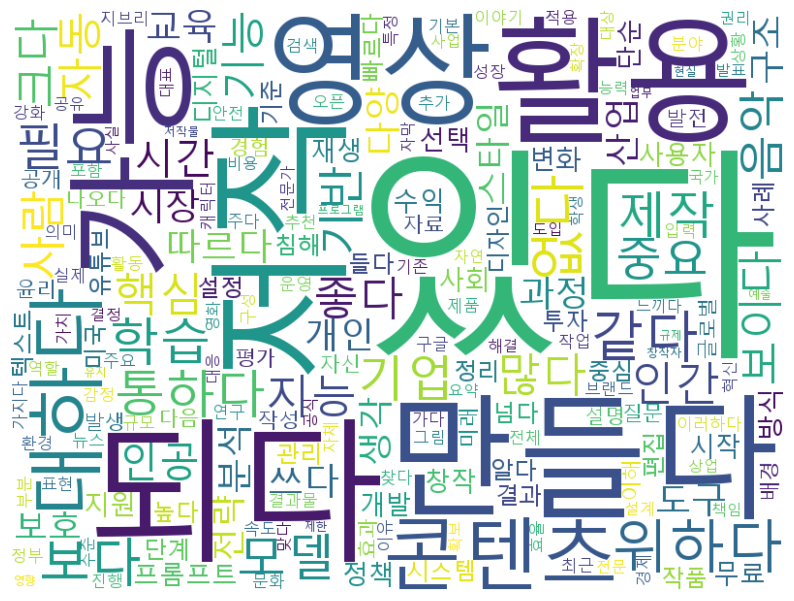

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 경로 (윈도우 기준)
font_path = 'C:/Windows/Fonts/malgun.ttf'

wc = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800,
    height=600
)

# doc_top (단어: 빈도 dict) 사용
wc.generate_from_frequencies(df_words)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# 본문-명사 워드클라우드

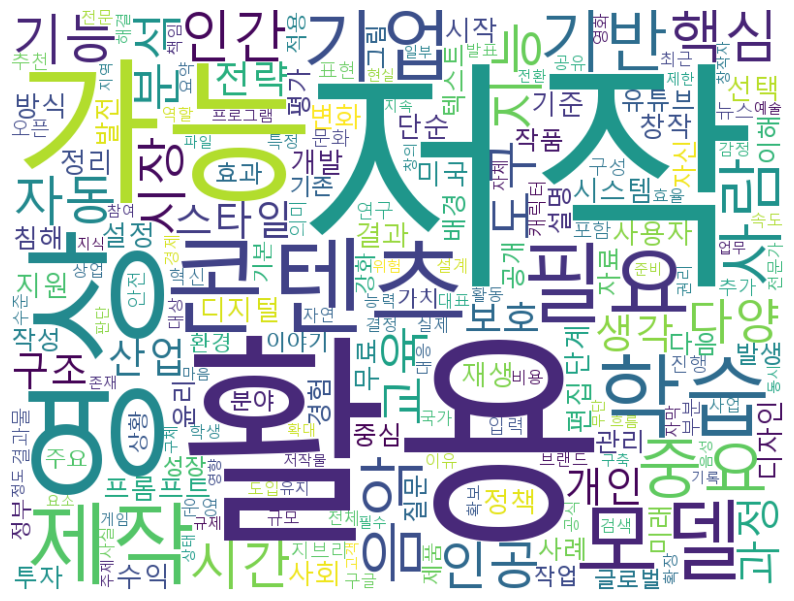

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = list(itertools.chain(*df['본문_명사']))
df_words = Counter(all_words)

# 한글 폰트 경로 (윈도우 기준)
font_path = 'C:/Windows/Fonts/malgun.ttf'

wc = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800,
    height=600
)

# doc_top (단어: 빈도 dict) 사용
wc.generate_from_frequencies(df_words)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# 본문-형용사 워드클라우드

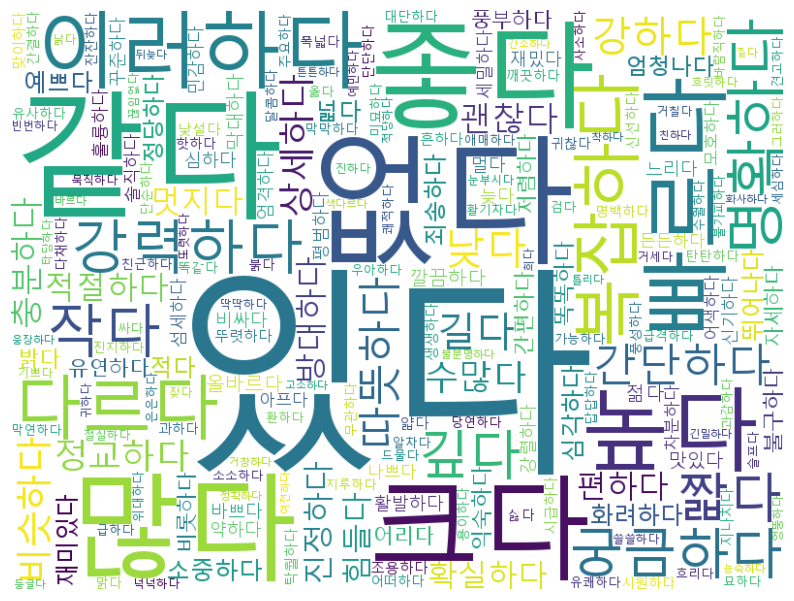

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = list(itertools.chain(*df['본문_형용사']))
df_words = Counter(all_words)

# 한글 폰트 경로 (윈도우 기준)
font_path = 'C:/Windows/Fonts/malgun.ttf'

wc = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800,
    height=600
)

# doc_top (단어: 빈도 dict) 사용
wc.generate_from_frequencies(df_words)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# 본문-동사 워드클라우드

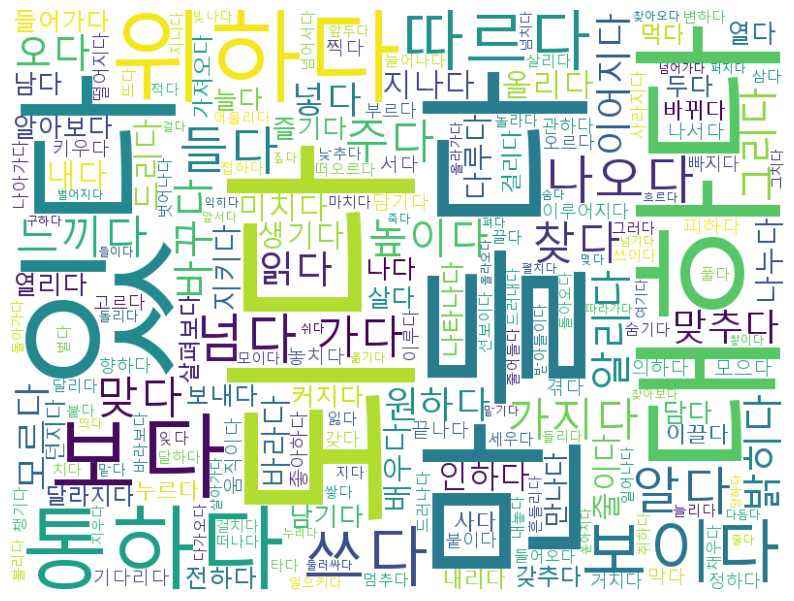

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = list(itertools.chain(*df['본문_동사']))
df_words = Counter(all_words)

# 한글 폰트 경로 (윈도우 기준)
font_path = 'C:/Windows/Fonts/malgun.ttf'

wc = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800,
    height=600
)

# doc_top (단어: 빈도 dict) 사용
wc.generate_from_frequencies(df_words)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [12]:
# 한글 폰트 적용
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 1. 한글 폰트 경로 설정 (Windows의 경우 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

# 2. Matplotlib의 기본 폰트를 설정한 폰트로 변경
rc('font', family=font_name)

# 3. 마이너스 기호가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"✅ 설정된 폰트: {font_name}")

✅ 설정된 폰트: Malgun Gothic


# 명사 + 동사/ 형용사 조합 2-gram 워드클라우드

#### 명사와 동사의 조합을 파악하면 본문의 어떤 맥락인지를 파악하기 쉬워 추가로 생성

🔗 n-gram 추출 및 불용어 필터링 시작...
🎯 추출된 유니크 n-gram: 491326개


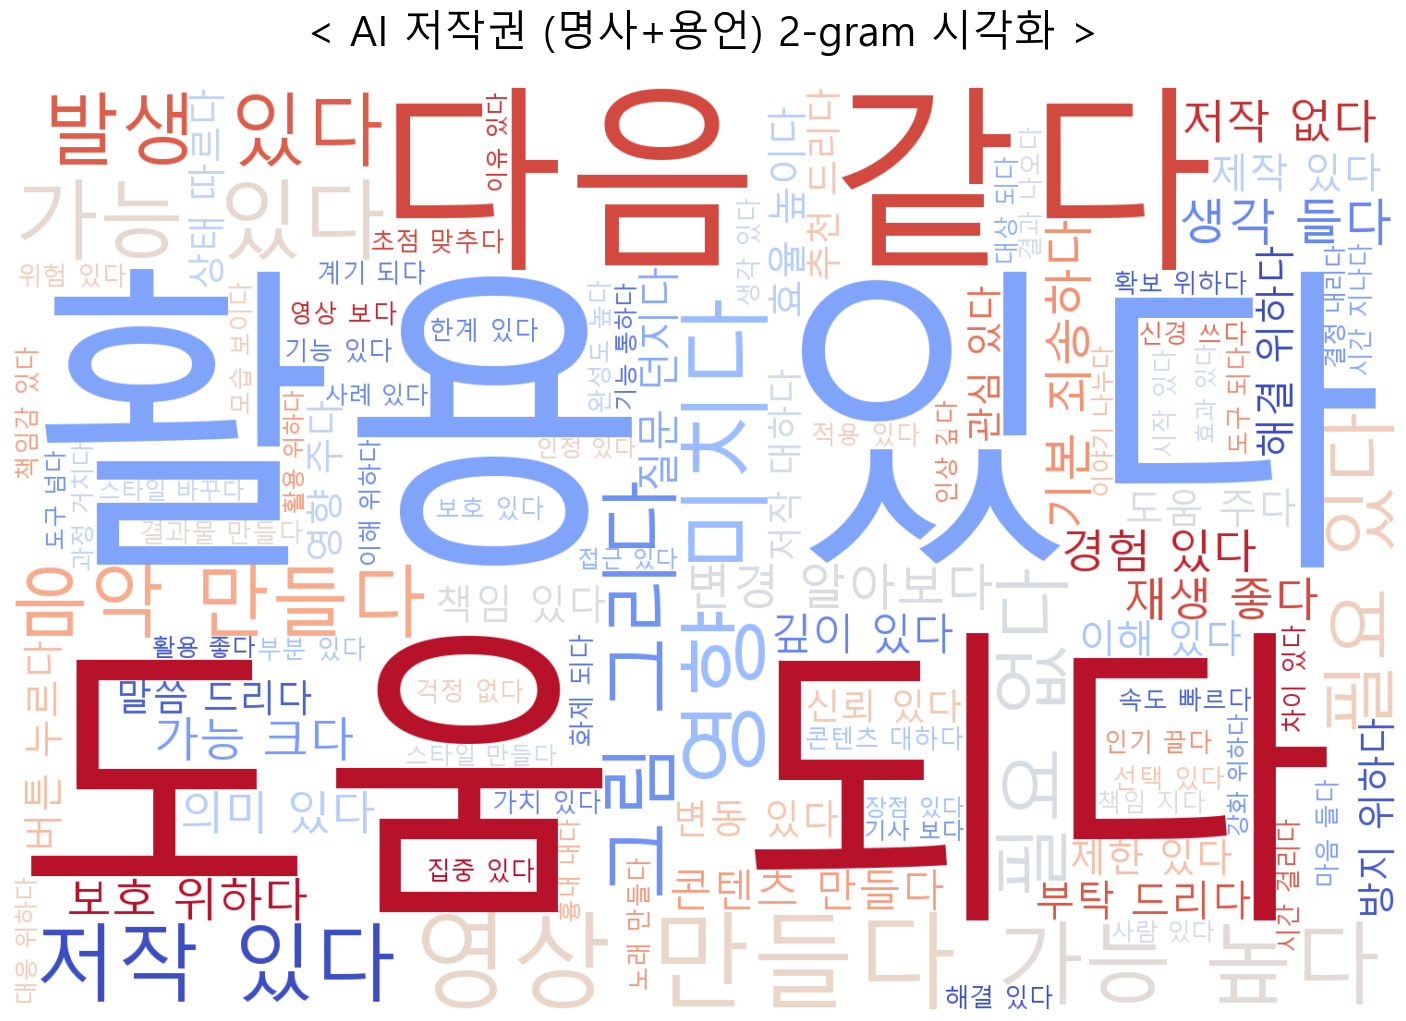


📊 상위 20개 n-gram 빈도 리스트:
활용 있다: 5553회
도움 되다: 5268회
다음 같다: 4468회
영상 만들다: 4136회
영향 미치다: 3349회
가능 높다: 3106회
가능 있다: 2938회
저작 있다: 2842회
그림 그리다: 2511회
발생 있다: 2506회
음악 만들다: 2457회
필요 없다: 2412회
필요 있다: 2312회
변경 알아보다: 2205회
기본 죄송하다: 2200회
생각 들다: 2173회
가능 크다: 1949회
의미 있다: 1854회
경험 있다: 1852회
보호 위하다: 1818회


In [13]:
import itertools
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

# 1. n-gram 추출 핵심 함수 정의
def extract_meaningful_ngrams(text, stopwords):
    """
    텍스트에서 [명사 + 용언] 형태의 n-gram만 추출하는 로직
    """
    if isinstance(text, str):
        tokens = text.split()
    elif isinstance(text, list):
        tokens = text
    else:
        return []

    ngram_res = []
    
    for i in range(len(tokens) - 1):
        w1 = tokens[i]
        w2 = tokens[i+1]
        
        # 조건: w1(명사/1글자초과) + w2(용언/'다'로 종료)
        # 불용어에 포함되지 않는 경우만 조합 생성
        if not w1.endswith('다') and w2.endswith('다'):
            if len(w1) > 1 and w1 not in stopwords and w2 not in stopwords:
                ngram_res.append(f"{w1} {w2}")
                
    return ngram_res

# ---------------------------------------------------------
# 2. 실행 및 데이터 변환
# ---------------------------------------------------------
print("🔗 n-gram 추출 및 불용어 필터링 시작...")

# 전체 문서에 대해 n-gram 추출 실행
df['final_ngrams'] = df['본문_정제표현'].apply(lambda x: extract_meaningful_ngrams(x, stopwords))

# 모든 n-gram을 하나의 리스트로 통합
all_ngrams = list(itertools.chain(*df['final_ngrams']))

# 빈도 분석
ngram_counts = Counter(all_ngrams)

# 워드클라우드용 상위 100개 사전 생성
doc_top_ngram = dict(ngram_counts.most_common(100))

# ---------------------------------------------------------
# 3. n-gram 전용 워드클라우드 시각화
# ---------------------------------------------------------
if not doc_top_ngram:
    print("⚠️ 결과가 비어있습니다. '다'로 끝나는 용언이 포함되어 있는지 확인하세요.")
else:
    print(f"🎯 추출된 유니크 n-gram: {len(ngram_counts)}개")
    
    font_path = 'C:/Windows/Fonts/malgun.ttf' # 윈도우 기준

    wc = WordCloud(
        font_path=font_path,
        background_color='white',
        width=1500, height=1000,
        max_words=100,
        colormap='coolwarm',     # 긍부정 뉘앙스를 잘 보여주는 테마
        prefer_horizontal=0.9
    )

    wc.generate_from_frequencies(doc_top_ngram)

    plt.figure(figsize=(18, 12))
    plt.imshow(wc, interpolation='bilinear')
    plt.title("< AI 저작권 (명사+용언) 2-gram 시각화 >", size=30, pad=30)
    plt.axis('off')
    plt.show()

# 4. 결과 출력 (상위 20개 리스트 확인)
print("\n📊 상위 20개 n-gram 빈도 리스트:")
for word, count in ngram_counts.most_common(20):
    print(f"{word}: {count}회")

# k-means 
#### 뉴클리드 거리에 의한 군집화

In [14]:
# [1] 데이터 준비
import pandas as pd

# 1. 문서 집합 만들기 (본문_정제표현 사용)
# 리스트 형태인 경우 공백으로 합치고, 문자열인 경우 그대로 사용합니다.
doc_corpus = []
for i in range(len(df)):
    text = df['본문_정제표현'].iloc[i]
    if isinstance(text, list):
        doc_corpus.append(' '.join(text))
    else:
        doc_corpus.append(str(text))

print(f"✅ 총 {len(doc_corpus)}건의 문서가 준비되었습니다.")
print(f"📝 첫 번째 문서: {doc_corpus[0][:50]}...")

✅ 총 28879건의 문서가 준비되었습니다.
📝 첫 번째 문서: 신생 출판사 도서 출간 계획 밝히다 업계 이목 집중 전통 출판 방식 뛰어넘다 도전 많다 가...


In [15]:
# -------------------------------------------------------------------------
# TF-IDF 벡터화
# -------------------------------------------------------------------------
# 문서를 숫자 벡터로 변환하여 K-Means 군집분석이 가능하도록 만듭니다.
# 자주 등장하지만 변별력이 낮은 단어는 낮은 가중치를 받고,
# 특정 문서군에서 상대적으로 중요한 단어는 높은 가중치를 받습니다.

# [2] TF-IDF 벡터화 및 표 생성
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF 설정 (제안하신 min_df=0.01 반영)
vec_x = TfidfVectorizer(min_df=0.01, max_df=0.95)
X = vec_x.fit_transform(doc_corpus)

# 2. TF-IDF 결과를 데이터프레임으로 변환 (표 작성)
tfidf_matrix = pd.DataFrame(X.toarray(), columns=vec_x.get_feature_names_out())

print(f"✅ TF-IDF 표 생성이 완료되었습니다. (단어 개수: {len(vec_x.get_feature_names_out())}개)")

✅ TF-IDF 표 생성이 완료되었습니다. (단어 개수: 3517개)


## 엘보우 함수를 통해 급격하게 줄어들던 오차가 완만해지기 시작하는 꺾임 지점을 확인

🔍 최적의 K를 찾기 위해 SSE 계산 중...


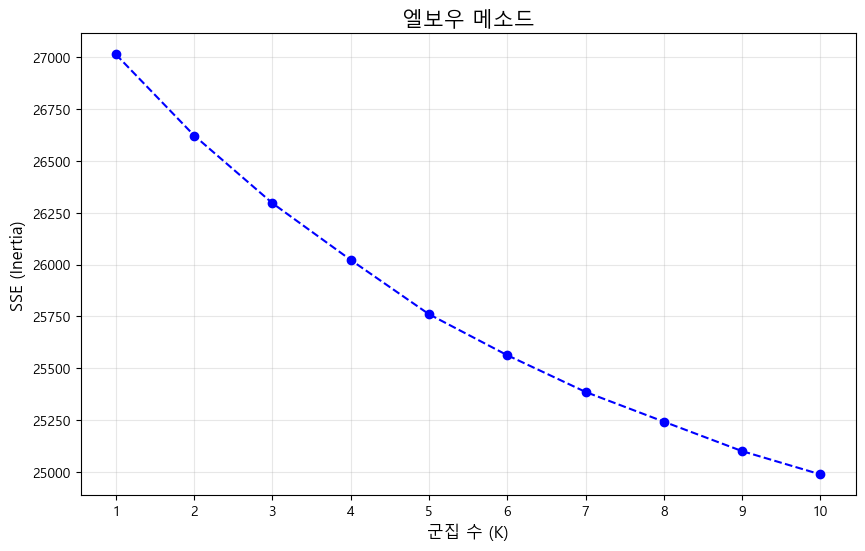

In [16]:
# [3] 엘보우 메소드 시각화
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (에러 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sse = [] # 오차제곱합
K_range = range(1, 11) # K를 1부터 10까지 테스트

print("🔍 최적의 K를 찾기 위해 SSE 계산 중...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# 2. 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(K_range, sse, marker='o', linestyle='--', color='b')
plt.title('엘보우 메소드', fontsize=15)
plt.xlabel('군집 수 (K)', fontsize=12)
plt.ylabel('SSE (Inertia)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

## 실루엣 계수 : 전체 평균 실루엣 계수가 1에 가까울수록 좋으며, 동시에 모든 군집의 실루엣 계수가 고르게 높을 때를 선택합니다. 특정 군집만 너무 높거나 낮은 것은 피해야 합니다.

🚀 실루엣 계수 계산 중... (데이터 양에 따라 시간이 걸릴 수 있습니다)
k=2 일 때 실루엣 계수: 0.0084
k=3 일 때 실루엣 계수: 0.0109
k=4 일 때 실루엣 계수: 0.0147
k=5 일 때 실루엣 계수: 0.0160
k=6 일 때 실루엣 계수: 0.0173
k=7 일 때 실루엣 계수: 0.0176
k=8 일 때 실루엣 계수: 0.0205
k=9 일 때 실루엣 계수: 0.0221
k=10 일 때 실루엣 계수: 0.0227


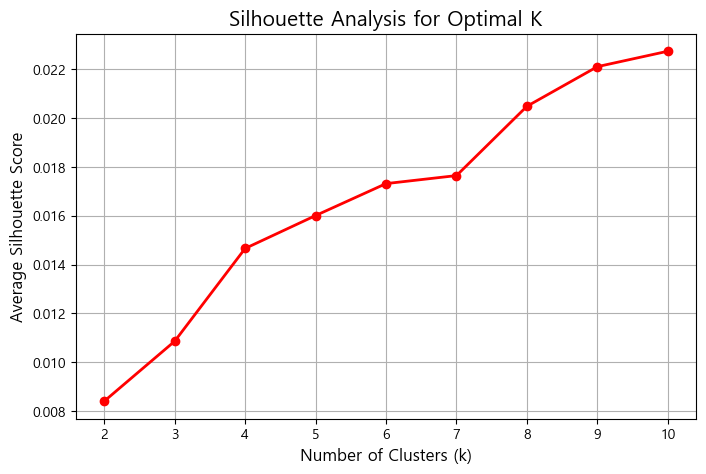

In [17]:
# -------------------------------------------------------------------------
# TF-IDF 벡터화
# -------------------------------------------------------------------------
# 문서를 숫자 벡터로 변환하여 K-Means 군집분석이 가능하도록 만듭니다.
# 자주 등장하지만 변별력이 낮은 단어는 낮은 가중치를 받고,
# 특정 문서군에서 상대적으로 중요한 단어는 높은 가중치를 받습니다.

from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans  # 1. KMeans 임포트 추가
import matplotlib.pyplot as plt
# 실루엣 계수를 저장할 리스트
silhouettes = []
# 엘보우에서 테스트했던 k 범위를 그대로 사용하세요 (예: 2~10)
k_range = range(2, 11) 

print("🚀 실루엣 계수 계산 중... (데이터 양에 따라 시간이 걸릴 수 있습니다)")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tfidf_matrix) # tfidf_matrix는 파일에 선언된 변수명
    
    # 실루엣 점수 계산
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    silhouettes.append(silhouette_avg)
    print(f"k={k} 일 때 실루엣 계수: {silhouette_avg:.4f}")

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouettes, 'ro-', linewidth=2)
plt.title('Silhouette Analysis for Optimal K', fontsize=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.grid(True)
plt.show()

🚀 CH Index 계산 시작...
k=2 일 때 CH Index: 424.09
k=3 일 때 CH Index: 393.74
k=4 일 때 CH Index: 366.38
k=5 일 때 CH Index: 350.88
k=6 일 때 CH Index: 327.48
k=7 일 때 CH Index: 308.33
k=8 일 때 CH Index: 289.20
k=9 일 때 CH Index: 274.87
k=10 일 때 CH Index: 259.80


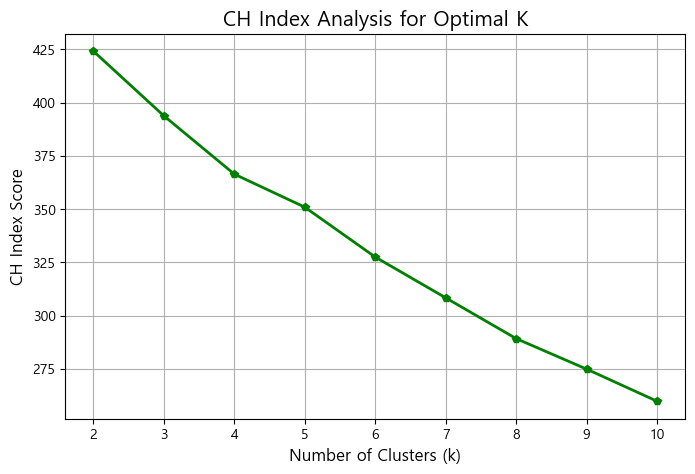

In [18]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 지표를 저장할 리스트
ch_scores = []
k_range = range(2, 11) # 실루엣과 동일한 범위

print("🚀 CH Index 계산 시작...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix)
    
    # CH Index 계산 (점수가 높을수록 좋음)
    score = calinski_harabasz_score(tfidf_matrix.values, labels)
    ch_scores.append(score)
    print(f"k={k} 일 때 CH Index: {score:.2f}")

# 2. 결과 시각화
plt.figure(figsize=(8, 5))
plt.plot(k_range, ch_scores, 'gp-', linewidth=2) # 초록색 펜타곤 마커
plt.title('CH Index Analysis for Optimal K', fontsize=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('CH Index Score', fontsize=12)
plt.grid(True)
plt.show()

🧹 불용어 필터링 적용 중...


100%|██████████| 28879/28879 [00:30<00:00, 936.01it/s] 


✅ 정제 완료: 28879건 -> 28838건 유지

🔍 군집별 대표 문서(Top 10) 정밀 확인

======= [ Cluster 0번 주제 확인 ] =======
Rank 1 (ID: 15786): 법률신문...
Rank 2 (ID: 14213): 법조 신문...
Rank 3 (ID: 13800): 법조 신문...
Rank 4 (ID: 4726): 업그레이드 제너레이션 장안 화제...
Rank 5 (ID: 16905): 부처 사리 모시다 설악산 봉정암 정책 보도 일일 종합 종합지 경제지 3사 국민 소통 대통령 아세안 정상 회의 아세안 정상 회의 참석 역내 경제 협력 강화 역설 국가 범죄 근절 의지 피력 캄보디아 정상회담 스캠 범죄 대응 코리아 전담 가동 합의 말레이 타결 자동차 철강 ...
Rank 6 (ID: 11235): 인공 지능 위하다 법률 개혁 산업 법제도 지능 사회 제도 임재 행정학 박사 서론 인공 지능 혁명 법률 패러다임 전환 산업 제도 한계 인공 지능 도래 도전 법률 개혁 필요 방향 인공 지능 법률 충돌 인공 지능 지위 권리 주체 인공 지능 인격 인정 인공 지능 권리 주체 확...
Rank 7 (ID: 11421): 인공 지능 위하다 법률 개혁 임재강 행정학 박사 서론 인공 지능 전환 인공 지능 발전 사회 패러다임 변화 인공 지능 전례 없다 속도 발전 사회 근간 뒤흔들다 처리 능력 비약 향상 알고리즘 고도 바탕 특정 영역 단순 반복 작업 넘다 인간 고유 영역 여기다 창작 판단 추론...
Rank 8 (ID: 27145): 상락아정 고요 구글 포토 일산위시티 수선화 매화까지 수선화 잔디 라일락 냉이 조팝나무꽃 명자 나무 팽나무 벚꽃 단풍 벚꽃 목련 제비꽃 돌단풍 명자나무꽃 미국 제비꽃 산수유 벚꽃 목련 매화 영춘화 홍매화 주름잎 제비꽃 벚꽃 별꽃 조팝나무꽃망울 산수유 매화 국회 일정 본회...
Rank 9 (ID: 9400): 최신 동향 논문 최근 일주일 동안 분야 규모 언어 모델 출시 활용 발전 혁신 연구 성과 두드러지다 양자 컴퓨팅 결합 

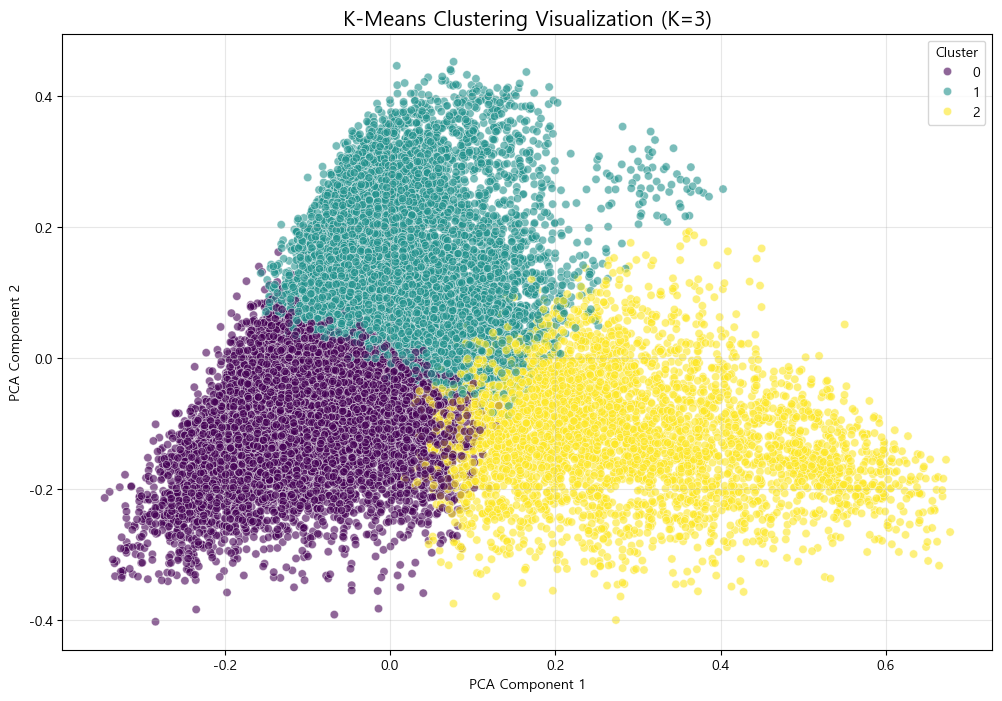

In [19]:
# -------------------------------------------------------------------------
# TF-IDF 벡터화
# -------------------------------------------------------------------------
# 문서를 숫자 벡터로 변환하여 K-Means 군집분석이 가능하도록 만듭니다.
# 자주 등장하지만 변별력이 낮은 단어는 낮은 가중치를 받고,
# 특정 문서군에서 상대적으로 중요한 단어는 높은 가중치를 받습니다.

import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

# tqdm 적용
tqdm.pandas()

# 1. 원본(df)에서 정제본(df_refined) 생성 및 1차 결측치 제거
# 원본 데이터의 '본문_정제표현' 컬럼이 아예 비어있는 행부터 정리합니다.
df_refined = df.dropna(subset=['본문_정제표현']).copy()

# 2. 불용어 필터링 함수 적용 (작성하신 filter_stopwords 함수 사용)
print("🧹 불용어 필터링 적용 중...")
df_refined['본문_정제표현'] = df_refined['본문_정제표현'].progress_apply(filter_stopwords)

# 3. 정제 후 빈 리스트([])가 된 행들을 NaN으로 바꿔서 날리기
# 배리어프리, 키오스크 같은 단어만 있던 문장은 정제 후 빈 값이 되므로 이를 제거합니다.
df_refined['본문_정제표현'] = df_refined['본문_정제표현'].apply(lambda x: x if isinstance(x, list) and len(x) > 0 else np.nan)
df_refined = df_refined.dropna(subset=['본문_정제표현'])

# 4. 인덱스 재정렬 (원본 df와 인덱스가 섞이지 않도록 새로 번호를 매깁니다)
df_refined = df_refined.reset_index(drop=True)
print(f"✅ 정제 완료: {len(df)}건 -> {len(df_refined)}건 유지")

# 5. [중요] 정제된 데이터 개수에 딱 맞는 새로운 TF-IDF 행렬 생성
# 리스트 형태를 문자열로 합쳐서 벡터화합니다.
tfidf_vectorizer = TfidfVectorizer(max_features=1000) # 설정값은 기존과 동일하게 유지
texts_refined = df_refined['본문_정제표현'].apply(lambda x: " ".join(x))
X_refined = tfidf_vectorizer.fit_transform(texts_refined)

# 6. K-Means 학습 (정제된 행렬 X_refined 사용)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
df_refined['cluster'] = kmeans.fit_predict(X_refined)

# 7. 군집별 중심점 근처 상위 10개 문서 확인
distances = pairwise_distances(X_refined, kmeans.cluster_centers_)

print("\n🔍 군집별 대표 문서(Top 10) 정밀 확인")
for cluster_num in range(n_clusters):
    print(f"\n======= [ Cluster {cluster_num}번 주제 확인 ] =======")
    closest_indices = np.argsort(distances[:, cluster_num])[:10]
    
    for rank, idx in enumerate(closest_indices):
        content = df_refined.iloc[idx]['본문_정제표현']
        text_display = " ".join(content) if isinstance(content, list) else str(content)
        print(f"Rank {rank+1} (ID: {idx}): {text_display[:150]}...")
    print("="*50)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# [주의] 반드시 df_refined와 X_refined(또는 새로 만든 행렬)를 사용해야 합니다!

# 1. 차원 축소 (PCA 활용)
# df_refined의 개수에 맞춰 생성된 X_refined를 사용합니다.
pca = PCA(n_components=2, random_state=42)
# 만약 sparse matrix라면 .toarray()가 필요할 수 있습니다.
pca_vecs = pca.fit_transform(X_refined.toarray()) 

# 2. 결과값을 df_refined에 할당 (df가 아니라 df_refined입니다!)
df_refined['x0'] = pca_vecs[:, 0]
df_refined['x1'] = pca_vecs[:, 1]

# 3. 시각화
plt.figure(figsize=(12, 8))
# data 파라미터에 df_refined를 넣어야 x0, x1과 cluster 개수가 딱 맞습니다.
sns.scatterplot(data=df_refined, x='x0', y='x1', hue='cluster', palette='viridis', alpha=0.6)

plt.title(f'K-Means Clustering Visualization (K={n_clusters})', fontsize=15)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

###  herence Score (응집도)
### 의미: 한 토픽 내의 상위 단어들이 서로 얼마나 의미적으로 유사한지를 측정합니다.
### 판단: 점수가 높을수록 좋습니다. (보통 0.4~0.7 정도면 양호하다고 봅니다.)

### Perplexity (혼란도)
### 의미: 확률 모델이 학습 데이터를 얼마나 잘 예측하는지를 나타냅니다.
### 판단: 점수가 낮을수록 모델이 데이터를 잘 학습했다는 뜻입니다.

# LDA

In [20]:
#!pip install gensim
#!pip install pyLDAvis

In [21]:
import gensim
from gensim import corpora

# 1. 데이터 준비 (본문_정제표현 컬럼 사용)
# 리스트 형태가 아닌 경우를 대비해 안전하게 처리합니다.
data_words = [text if isinstance(text, list) else str(text).split() for text in df['본문_정제표현']]

# 2. Gensim 사전(Dictionary) 생성
# 모든 문서에 등장하는 단어에 고유 번호를 부여합니다.
id2word = corpora.Dictionary(data_words)

# 3. 필터링 (너무 흔하거나 너무 드문 단어 제거)
# 10개 미만의 문서에만 등장하거나, 전체의 50% 이상 차지하는 단어 제외

id2word.filter_extremes(no_below=10, no_above=0.5)

# 4. 말뭉치(Corpus) 생성: 문서를 (단어 ID, 빈도) 형태로 변환
corpus = [id2word.doc2bow(text) for text in data_words]

print(f"✅ 사전 생성 완료: 총 {len(id2word)}개의 유니크 단어")
print(f"✅ 말뭉치 생성 완료: {len(corpus)}개의 문서 변환됨")

✅ 사전 생성 완료: 총 23414개의 유니크 단어
✅ 말뭉치 생성 완료: 28879개의 문서 변환됨


In [22]:
# 1. LDA 모델 학습
# num_topics: 아까 정한 군집 수 적용
# passes: 전체 데이터를 훑는 횟수 (정교한 분석을 위해 15회 권장)
print("🚀 LDA 모델 학습 시작... (시간이 다소 소요될 수 있습니다)")
lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=3    , 
    random_state=100,
    update_every=1,
    chunksize=100,
    passes=15,
    alpha='auto',
    per_word_topics=True
)

print("✅ LDA 모델 학습 완료!")

🚀 LDA 모델 학습 시작... (시간이 다소 소요될 수 있습니다)
✅ LDA 모델 학습 완료!


In [23]:
!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models as gensim_models

# 시각화 데이터 준비
print("🎨 시각화 준비 중...")
vis = gensim_models.prepare(lda_model, corpus, id2word)

# 노트북 내 출력
pyLDAvis.display(vis)


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


🎨 시각화 준비 중...


In [24]:
from gensim.models import CoherenceModel

def compute_lda_metrics(dictionary, corpus, texts, limit, start=2, step=1):
    coherence_values = []
    perplexity_values = [] # 혼란도를 담을 리스트 추가
    model_list = []
    
    for num_topics in range(start, limit, step):
        # 1. LDA 모델 학습
        model = gensim.models.ldamodel.LdaModel(
            corpus=corpus, num_topics=num_topics, id2word=dictionary, 
            passes=10, random_state=100
        )
        model_list.append(model)
        
        # 2. Coherence(응집도) 계산: 높을수록 좋음
        coherencemodel = CoherenceModel(
            model=model, texts=texts, dictionary=dictionary, coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
        
        # 3. Perplexity(혼란도) 계산: 낮을수록 좋음 (★ 추가된 부분)
        # log_perplexity는 로그값을 반환하므로 낮을수록 모델이 데이터를 잘 설명합니다.
        perplexity_values.append(model.log_perplexity(corpus))
        
        print(f"K={num_topics} 완료: Coherence={coherence_values[-1]:.4f}, Perplexity={perplexity_values[-1]:.4f}")

    return model_list, coherence_values, perplexity_values

# 실행
start, limit, step = 2, 9, 1
model_list, coherence_v, perplexity_v = compute_lda_metrics(
    dictionary=id2word, corpus=corpus, texts=data_words, 
    start=start, limit=limit, step=step
)

K=2 완료: Coherence=0.4794, Perplexity=-8.0873
K=3 완료: Coherence=0.5325, Perplexity=-7.9685
K=4 완료: Coherence=0.5503, Perplexity=-7.9026
K=5 완료: Coherence=0.5681, Perplexity=-7.8788
K=6 완료: Coherence=0.5052, Perplexity=-7.8441
K=7 완료: Coherence=0.5715, Perplexity=-7.8100
K=8 완료: Coherence=0.5814, Perplexity=-7.8146


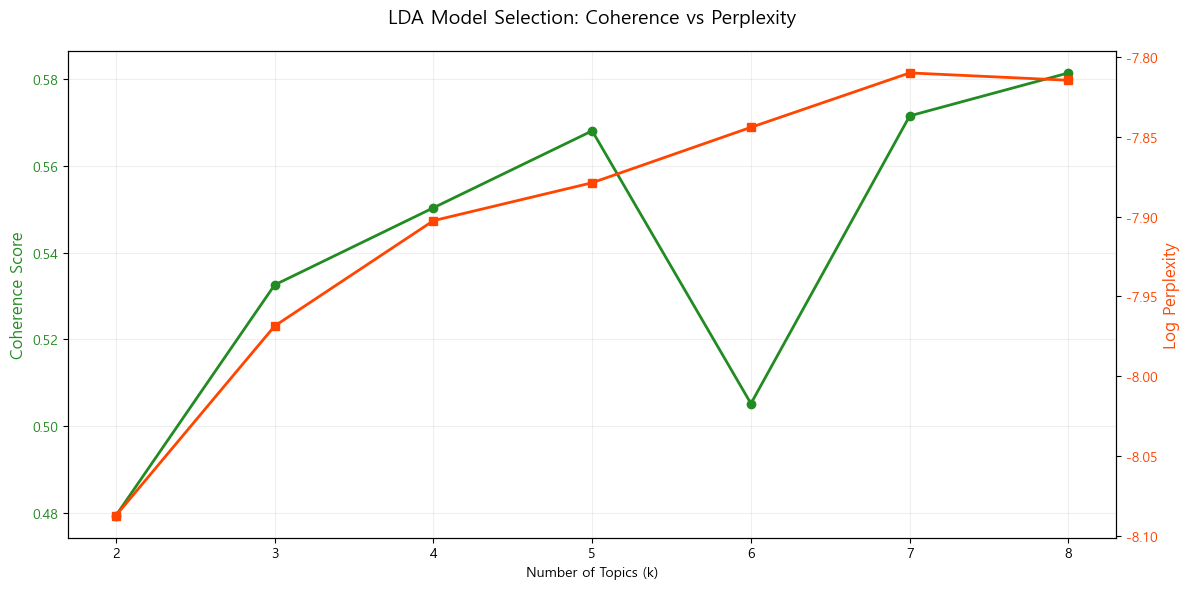

In [25]:
# 1. 그래프 데이터 설정
x = range(start, limit, step)

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- 왼쪽 축: Coherence (높을수록 좋음) ---
ax1.set_xlabel('Number of Topics (k)')
ax1.set_ylabel('Coherence Score', color='forestgreen', fontsize=12)
ax1.plot(x, coherence_v, marker='o', color='forestgreen', linewidth=2, label='Coherence')
ax1.tick_params(axis='y', labelcolor='forestgreen')
ax1.grid(True, alpha=0.2)

# --- 오른쪽 축: Perplexity (낮을수록 좋음) ---
ax2 = ax1.twinx() # x축을 공유하는 보조축 생성
ax2.set_ylabel('Log Perplexity', color='orangered', fontsize=12)
ax2.plot(x, perplexity_v, marker='s', color='orangered', linewidth=2, label='Perplexity')
ax2.tick_params(axis='y', labelcolor='orangered')

# 제목 및 레이아웃
plt.title("LDA Model Selection: Coherence vs Perplexity", fontsize=14, pad=20)
fig.tight_layout() 

# 최적 지점 표시 (호성님이 선택한 K=6 지점에 강조 표시)
plt.show()

# 결과 출력
best_coherence_k = x[coherence_v.index(max(coherence_v))]

## 교수님 지금부터 하단에 있는 코드는 실행시 결과물이 바뀔 수 있습니다.
## random_state 값을 임의 상수로 수정하는게 맞는데, RANDOM으로 학습하고 파일로 저장하는 형식으로 구성하여서
## 다시 학습을 다시 돌렸을때 결과가 다르게 나올 수 있습니다. 제가 이 부분을 놓쳤습니다. 죄송합니다.

## 제공드린 PPT 발표 자료는 6월 13일, 최종 실행 산출물을 기준으로 작성했습니다.

In [1]:
# -------------------------------------------------------------------------
# BERTopic 모델링 실행
# -------------------------------------------------------------------------
# 문장 임베딩, UMAP 차원축소, HDBSCAN 군집화, c-TF-IDF 키워드 추출을 통해
# AI 저작권 담론을 의미 기반 토픽으로 분류합니다.
# 본 분석에서는 비교 가능성을 위해 토픽 수가 20개 내외로 유지되도록 설정했습니다.

# =========================================================================
# [1단계] 위젯 에러 / 진행바 문제 해결 환경 변수 설정
# =========================================================================
import os
os.environ["TQDM_DISABLE"] = "0"          
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["DISABLE_TQDM_NOTEBOOK"] = "1"

import sys
import csv
import tqdm
import tqdm.std
import tqdm.notebook
import tqdm.auto
import tqdm.autonotebook

tqdm.notebook.tqdm = tqdm.std.tqdm
tqdm.auto.tqdm = tqdm.std.tqdm
tqdm.autonotebook.tqdm = tqdm.std.tqdm
# =========================================================================

import pandas as pd
import numpy as np
import random

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer  
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN 
from umap import UMAP

file_path = globals().get("file_path", r"C:\Users\WHKONG\AI 저작권 여론 분석")

# =========================================================================
# [2단계] 데이터 로드 및 초강력 인덱스 청소
# =========================================================================
print("[1/6] 정제된 텍스트 로드 및 차원 동기화 작업 중...")
csv.field_size_limit(100000000)
df = pd.read_csv(
    os.path.join(file_path, "형태소분석 완료.csv"),
    encoding='utf-8-sig',
    dtype=object,
    engine='python',
    on_bad_lines='skip'
)

# 1. 1차 결측치 제거
df = df.dropna(subset=["본문_명사"]).reset_index(drop=True)

# 2. 불용어 및 숫자 정제 함수
def clean_tokens_for_bertopic(raw):
    if pd.isna(raw):
        return ""
    tokens = str(raw).split()
    kept = []
    for t in tokens:
        t = str(t).strip()
        # 앞단 불용어 정의 셀을 실행했다면 should_drop_token을 그대로 활용합니다.
        if "should_drop_token" in globals():
            if should_drop_token(t):
                continue
        else:
            import re as _re
            if _re.fullmatch(r"[\d.,\-+/%:]+", t) or len(t) <= 1:
                continue
        kept.append(t)
    return " ".join(kept)

df["본문_명사_토픽용"] = df["본문_명사"].map(clean_tokens_for_bertopic)

# 공백 문자 노이즈 완벽 살처분
df["본문_명사_토픽용"] = df["본문_명사_토픽용"].str.strip()
df["본문_명사_토픽용"] = df["본문_명사_토픽용"].replace("", np.nan)
df = df.dropna(subset=["본문_명사_토픽용"]).reset_index(drop=True) 

# 최종 코퍼스 확정
doc_corpus = df["본문_명사_토픽용"].tolist()
print(f"   - 🎯 완벽 인덱싱 완료된 최종 문서 수: {len(doc_corpus):,}개")

# =========================================================================
# [3단계] 한국어 임베딩 재계산
# =========================================================================
print("\n[2/6] 한국어 지원 임베딩 모델 로드 중...")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

print("\n[3/6] 동기화 상태로 문서 임베딩 새로 계산 중...")
embeddings = embedding_model.encode(
    doc_corpus,
    batch_size=32,
    show_progress_bar=True,   
    convert_to_numpy=True,
)
print(f"   - 📊 임베딩 매트릭스 차원: {embeddings.shape}")

# =========================================================================
# [4단계] 무적 버전 벡터라이저 및 c-TF-IDF 옵션 설정 (★0번 방 해체 밸런스 패치)
# =========================================================================
_vec_stop = [
    "것", "수", "등", "AI", "저작권", "년", "월", "일", "때", "관련", "사용", "내용",
    "이미지", "영상", "콘텐츠", "데이터", "정보", "활용", "문제", "작성자", "글"
]

# 외부 벡터라이저는 완벽하게 기본값 위주로 복귀 (min_df 제한 해제)
vectorizer_model = CountVectorizer(
    stop_words=_vec_stop,
    ngram_range=(1, 1)
)

# BERTopic 내부 가짜 에러 폭탄 제거 옵션
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=False)

# 재현성 고정: BERTopic 내부 UMAP이 실행마다 다른 저차원 좌표를 만들지 않도록 random_state를 명시합니다.
# 같은 전처리 결과와 같은 파라미터라면 토픽 결과가 최대한 동일하게 재현됩니다.
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)

# 💡 [밀집 해결 1] min_cluster_size를 25로 하향하여 0번 방 안의 촘촘한 경계를 더 세밀하게 찢어발깁니다.
cluster_model = HDBSCAN(
    min_cluster_size=25,     
    min_samples=3, 
    metric='euclidean', 
    cluster_selection_method='eom', 
    prediction_data=True
)

# 💡 [최종 설정] 발표/감성분석 기준을 맞추기 위해 토픽 수를 20개로 고정합니다.
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,  
    ctfidf_model=ctfidf_model,         
    umap_model=umap_model,
    hdbscan_model=cluster_model,       
    language="multilingual",
    calculate_probabilities=False,
    verbose=True,
        nr_topics=20,                       # 최종 토픽 수 20개 고정
)

# =========================================================================
# [5단계] 🚀 BERTopic 학습 시작 및 Outlier 재배치
# =========================================================================
print("\n[5/6] 🚀 BERTopic 학습 시작...")
topics, probs = topic_model.fit_transform(doc_corpus, embeddings=embeddings)

print("\n[6/6] 노이즈 데이터를 가장 유사한 토픽으로 재배치 중...")
new_topics = list(topics)
if -1 in new_topics:
    new_topics = topic_model.reduce_outliers(
        doc_corpus,
        topics,
        strategy="embeddings",
    )
    # 💡 아웃라이어 재배치 후 골고루 분산된 결과를 토픽 모델에 최종 반영합니다.
    topic_model.update_topics(doc_corpus, topics=new_topics)

# =========================================================================
# [6단계] 결과물 최종 저장 및 출력
# =========================================================================
df["topic_num"] = pd.Series(new_topics, dtype="int64")
topics = new_topics
# 주의: 아래 저장 코드는 기존 BERTopic_문서별_토픽.csv / BERTopic_토픽정보.csv를 덮어씁니다.
# 보고서에 사용한 결과를 보존하려면 실행 전 파일명을 바꾸거나 백업한 뒤 실행하세요.
bertopic_save = os.path.join(file_path, "BERTopic_문서별_토픽.csv")
topic_info_save = os.path.join(file_path, "BERTopic_토픽정보.csv")

df.to_csv(bertopic_save, index=False, encoding="utf-8-sig")
topic_model.get_topic_info().to_csv(topic_info_save, index=False, encoding="utf-8-sig")

topic_counts = df["topic_num"].value_counts().sort_index()
print(f"\n✅ BERTopic 20토픽 기준 저장 완료: {bertopic_save}")
print(f"✅ 토픽 정보 저장 완료: {topic_info_save}")
print("\n📊 [최종 결과] 토픽별 문서 수")
print(topic_counts)
print("\n📊 [최종 결과] 상위 20개 토픽 정보 리스트:")
display(topic_model.get_topic_info().head(25))


[1/6] 정제된 텍스트 로드 및 차원 동기화 작업 중...
   - 🎯 완벽 인덱싱 완료된 최종 문서 수: 28,836개

[2/6] 한국어 지원 임베딩 모델 로드 중...



[3/6] 동기화 상태로 문서 임베딩 새로 계산 중...


Batches:   0%|          | 0/902 [00:00<?, ?it/s]

2026-06-09 13:02:42,317 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


   - 📊 임베딩 매트릭스 차원: (28836, 384)

[5/6] 🚀 BERTopic 학습 시작...


2026-06-09 13:03:10,838 - BERTopic - Dimensionality - Completed ✓
2026-06-09 13:03:10,840 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 13:03:15,264 - BERTopic - Cluster - Completed ✓
2026-06-09 13:03:15,265 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-09 13:03:21,717 - BERTopic - Representation - Completed ✓
2026-06-09 13:03:21,731 - BERTopic - Topic reduction - Reducing number of topics
2026-06-09 13:03:21,879 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 13:03:28,079 - BERTopic - Representation - Completed ✓
2026-06-09 13:03:28,092 - BERTopic - Topic reduction - Reduced number of topics from 129 to 20



[6/6] 노이즈 데이터를 가장 유사한 토픽으로 재배치 중...


2026-06-09 13:15:20,455 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



✅ BERTopic 20토픽 기준 저장 완료: C:\Users\WHKONG\AI 저작권 여론 분석\BERTopic_문서별_토픽.csv
✅ 토픽 정보 저장 완료: C:\Users\WHKONG\AI 저작권 여론 분석\BERTopic_토픽정보.csv

📊 [최종 결과] 토픽별 문서 수
topic_num
0     12995
1      5818
2      2699
3      1018
4      1474
5       814
6       624
7       574
8       346
9       476
10      649
11      184
12      275
13      161
14      126
15      153
16       89
17      165
18      196
Name: count, dtype: int64

📊 [최종 결과] 상위 20개 토픽 정보 리스트:


,Topic,Count,Name,Representation,Representative_Docs
0,0,12995,0_이미지_저작_음악_생성,"[이미지, 저작, 음악, 생성, 사용, 가능, 스타일, 사진, 영상, 사람]",[요즘 콘텐츠 고민 부분 배경 음악 영상 분위기 음악 저작 문제 고려 음원 검색 시...
1,1,5818,1_데이터_기술_생성_활용,"[데이터, 기술, 생성, 활용, 저작, 정보, 기업, 콘텐츠, 모델, 지능]",[장점 한계 미래 혁신 분석 보고서 서론 인공 지능 시대 서막 청소년 역할 인공 지...
2,2,2699,2_교육_학생_학습_활용,"[교육, 학생, 학습, 활용, 생성, 인간, 문제, 교사, 수업, 기술]",[미래 과학 교육 인공 지능 최대한 활용 고등학교 교육 방법 전략 보고서 과학 교육...
3,3,1018,3_갤럭시_삼성_기능_전기,"[갤럭시, 삼성, 기능, 전기, 기술, 출시, 가능, 삼성전자, 모델, 배터리]",[최신 뉴스 루머 바탕 작성 참고 자료 기재 사양 출시 일정 제조사 공식 발표 변경...
4,4,1474,4_영상_편집_생성_제작,"[영상, 편집, 생성, 제작, 기능, 콘텐츠, 이미지, 사용, 자동, 자막]",[최근 유튜브 쇼츠 틱톡 콘텐츠 시장 급성장 임팩트 영상 제작 수요 영상 편집 경험...
5,5,814,5_시장_투자_기업_가격,"[시장, 투자, 기업, 가격, 변동, 시세, 제품, 플래시, 미국, 기술]",[이번 키워드 파월 트럼프 관세 정책 우려 파월 발언 이후 뉴욕 증시 급락세 대선 ...
6,6,624,6_미국_정책_대통령_정부,"[미국, 정책, 대통령, 정부, 중국, 트럼프, 국가, 정치, 사회, 경제]",[메인 뉴스 대선 주자 여야 대선 주자 현황 여론 조사 정리 윤석열 대통령 파면 조...
7,7,574,7_영화_디즈니_영상_저작,"[영화, 디즈니, 영상, 저작, 제작, 캐릭터, 콘텐츠, 생성, 기술, 이미지]",[기업 입장 공짜 무단 사용 컨텐츠 비용 지불 추가 회사 독보 기업 컨텐츠 제공 컨...
8,8,346,8_음성_목소리_영상_오디오,"[음성, 목소리, 영상, 오디오, 기능, 기술, 콘텐츠, 제작, 사용, 생성]",[음성 생성 작업 자동 인건비 관련 비용 비용 효율 대안 제공 생성 머신 러닝 기술...
9,9,476,9_콘텐츠_영상_블로그_인스타그램,"[콘텐츠, 영상, 블로그, 인스타그램, 이미지, 저작, 사용, 수익, 활용, 자동]",[인스타그램 영상 업로드 이유 해결책 정리 인스타그램 특별 순간 공유 영상 업로드 ...


### 1. 토픽 간 거리 지도 (Intertopic Distance Map)
### [의미] "우리 데이터의 전체적인 지형도"

In [2]:
import plotly.graph_objects as go

# PCA나 UMAP으로 차원을 축소하여 토픽들의 관계를 2차원 평면에 보여줍니다.
# 크기를 키우고 상위 10개 토픽만 시각화 (가독성 확보)
# topic_model.visualize_topics(top_n_topics=10, width=1000, height=800)

# 1. 기본 시각화 객체 생성
fig = topic_model.visualize_topics(top_n_topics=20, width=1000, height=800)

# 2. 그래프 데이터에서 좌표와 토픽 번호 추출 (보통 0번 데이터에 몰려 있음)
# Scatter 객체에서 x, y 좌표와 표시될 텍스트(번호)를 가져옵니다.
x_coords = fig.data[0].x
y_coords = fig.data[0].y
# 기본적으로 hovertext나 text에 번호 정보가 들어있습니다.
topic_labels = [str(i) for i in range(len(x_coords))] 

# 3. 텍스트 레이어 추가
fig.add_trace(
    go.Scatter(
        x=x_coords,
        y=y_coords,
        mode="text",
        text=topic_labels, # 토픽 번호 리스트
        textposition="middle center", # 원의 정중앙에 번호 배치
        textfont=dict(family="Arial", size=15, color="black"),
        showlegend=False,
        hoverinfo='skip' # 번호 텍스트에는 마우스 반응 제외
    )
)

fig.show()

### 2. 토픽별 단어 막대그래프 (Topic Word Scores)
### [의미] "각 토픽의 정체성과 디테일"

In [3]:
# top_n_topics로 보고 싶은 상위 토픽 개수를 조절할 수 있습니다.


# topic_model.visualize_barchart(top_n_topics=10)

# n_words를 15로 설정하면 토픽당 15개의 핵심 단어가 나옵니다.
fig_bar = topic_model.visualize_barchart(
    top_n_topics=20, 
    n_words=15,      # 이 부분을 수정하세요!
    width=500,      # 단어가 많아지니 가로 길이를 충분히 넓게 잡는 게 좋습니다.
    height=300       # 세로 크기도 함께 조절하세요.
)

# 그래프 출력
fig_bar.show()

# 고화질 저장 (단어가 많으니 scale을 높여서 저장 추천)
try:
    fig_bar.write_image("topic_barchart_detailed.png", scale=2)
except Exception as e:
    print(f"PNG 저장 생략 (pip install kaleido): {e}")

PNG 저장 생략 (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



### 3. 토픽 계층 구조 (Hierarchical Clustering)
### [의미] "주제들의 계보와 뿌리"

In [4]:
# 현재 모델에 실제 존재하는 토픽 번호를 기준으로 계층 구조를 시각화합니다.
custom_labels = topic_model.generate_topic_labels(nr_words=3, topic_prefix=True)
topic_info = topic_model.get_topic_info()
topics_to_show = topic_info.loc[topic_info["Topic"] != -1, "Topic"].astype(int).tolist()[:20]

topic_model.visualize_hierarchy(
    topics=topics_to_show,
    custom_labels=custom_labels,
)


### 4. 토픽 유사도 히트맵 (Topic Similarity Heatmap)
### [의미] AI 저작권 담론에서 어떤 토픽들이 서로 가까운 문맥으로 묶이는지 확인합니다.

해석: 가로축과 세로축에 토픽 번호를 나열하고, 교차 지점의 색이 진할수록 두 토픽이 유사한 문맥을 공유한다는 뜻입니다.

활용: 이미지 생성/스타일 모방 토픽과 저작권 판단 기준 토픽이 가까우면, 기술 활용 논의와 권리 판단 논의가 함께 등장한다는 근거로 해석할 수 있습니다.


In [5]:
topic_model.visualize_heatmap()

# 딥러닝 기반 감성분석 · 토픽별 감성분석 · 시계열 여론 동향

- **BERTopic** `topic_num` + **KNU** 감성(긍·중·부)
- `작성날짜` 기준 주·월 **시계열 여론 동향**

> BERTopic 학습 셀을 먼저 실행하세요.



📌 최신 BERTopic 결과 로드
📌 기존 문서 단위 딥러닝 감성 결과 재사용 + 최신 topic_num 재결합
   - Missing sentiment after merge: 0 / 28,813
✅ 최신 topic_num 반영 딥러닝 감성 결과 저장: C:\Users\WHKONG\AI 저작권 여론 분석\딥러닝_감성분석_결과.csv
   - ABSA_TOPIC_NAME_FIX_V3 active
   - Topic names loaded for ABSA table: 19 topics
✅ 토픽별 딥러닝 ABSA 저장: C:\Users\WHKONG\AI 저작권 여론 분석\토픽별_딥러닝_ABSA.csv
   - 집계 토픽 수: 19개


,토픽명,topic_num,문서수,평균감성점수,긍정비율,부정비율,중립비율
0,T0: 0_이미지_저작_음악_생성,0,12992,-0.031,3.80,6.87,89.33
1,T1: 1_데이터_기술_생성_활용,1,5806,-0.038,5.89,9.65,84.46
2,T2: 2_교육_학생_학습_활용,2,2697,-0.031,2.00,5.12,92.88
4,T4: 4_영상_편집_생성_제작,4,1474,0.036,6.04,2.44,91.52
3,T3: 3_갤럭시_삼성_기능_전기,3,1018,0.058,11.10,5.30,83.60
5,T5: 5_시장_투자_기업_가격,5,813,-0.146,9.84,24.48,65.68
10,T10: 10_저작_소송_법원_학습,10,648,-0.275,4.17,31.64,64.20
6,T6: 6_미국_정책_대통령_정부,6,622,-0.193,4.18,23.47,72.35
7,T7: 7_영화_디즈니_영상_저작,7,574,-0.211,8.36,29.44,62.20
9,T9: 9_콘텐츠_영상_블로그_인스타그램,9,476,-0.048,2.94,7.77,89.29


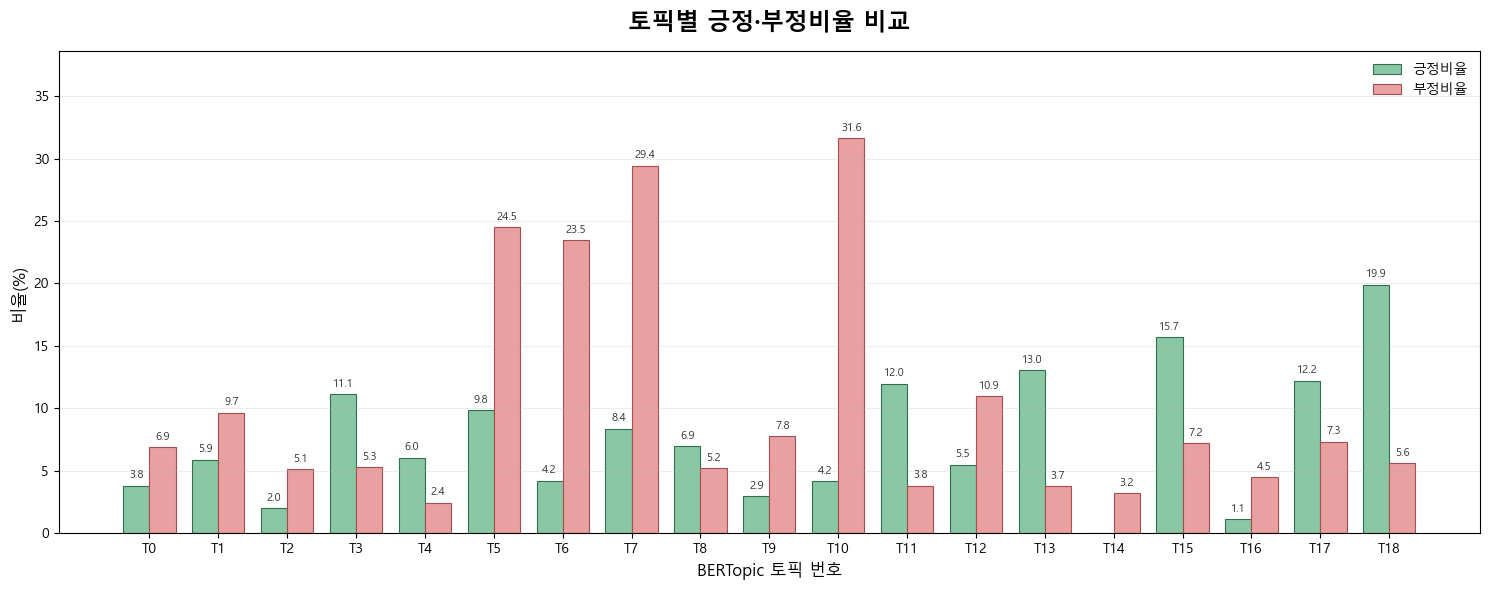

✅ ABSA 토픽별 긍정·부정비율 막대그래프 저장: C:\Users\WHKONG\AI 저작권 여론 분석\ABSA_토픽별_긍부정비율_막대그래프.png


In [1]:
# -------------------------------------------------------------------------
# BERTopic 결과와 감성분석 결과 재결합
# -------------------------------------------------------------------------
# 최신 BERTopic의 topic_num을 문서 단위 감성분석 결과와 다시 결합합니다.
# 이후 토픽별 평균 감성점수와 긍정/부정/중립 비율을 계산하여
# 토픽별 갈등 강도를 확인하는 ABSA 표를 생성합니다.

# =========================================================================
# [1] 최신 BERTopic 기준 딥러닝 감성 결과 재결합 및 토픽별 ABSA 산출
# =========================================================================
import os
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

file_path = globals().get("file_path", r"C:\Users\WHKONG\AI 저작권 여론 분석")
BER_TOPIC_CSV = os.path.join(file_path, "BERTopic_문서별_토픽.csv")
DL_SENTIMENT_CSV = os.path.join(file_path, "딥러닝_감성분석_결과.csv")
ABSA_CSV = os.path.join(file_path, "토픽별_딥러닝_ABSA.csv")
KNU_ABSA_CSV = os.path.join(file_path, "토픽별_감성분석_통계표.csv")
TOPIC_INFO_CSV = os.path.join(file_path, "BERTopic_토픽정보.csv")
JSON_PATH = os.path.join(file_path, "SentiWord_info.json")

def read_csv_safe(path):
    return pd.read_csv(path, encoding="utf-8-sig", dtype=object, engine="python", on_bad_lines="skip")

def add_duplicate_order_key(frame, key_cols):
    out = frame.copy()
    out["_dup_order"] = out.groupby(key_cols, dropna=False).cumcount()
    return out

def pct(series, label):
    return round((series.astype(str).eq(label).mean() * 100), 2)

print("📌 최신 BERTopic 결과 로드")
topic_df = read_csv_safe(BER_TOPIC_CSV)
topic_df["topic_num"] = pd.to_numeric(topic_df["topic_num"], errors="coerce")
topic_df = topic_df.dropna(subset=["topic_num", "제목", "작성날짜", "링크", "본문"]).copy()
topic_df["topic_num"] = topic_df["topic_num"].astype(int)

key_cols = ["제목", "작성날짜", "링크", "본문"]
dl_needed = ["dl_sentiment_label", "dl_sentiment_score", "dl_prob_positive", "dl_prob_neutral", "dl_prob_negative"]

if os.path.exists(DL_SENTIMENT_CSV):
    print("📌 기존 문서 단위 딥러닝 감성 결과 재사용 + 최신 topic_num 재결합")
    sent_df = read_csv_safe(DL_SENTIMENT_CSV)
    missing = [c for c in dl_needed if c not in sent_df.columns]
    if missing:
        raise ValueError(f"딥러닝 감성 결과 CSV에 필요한 컬럼이 없습니다: {missing}")
    sent_df = sent_df.dropna(subset=key_cols).copy()
    left = add_duplicate_order_key(topic_df, key_cols)
    right = add_duplicate_order_key(sent_df, key_cols)[key_cols + ["_dup_order"] + dl_needed]
    df = left.merge(right, on=key_cols + ["_dup_order"], how="left")
    missing_sent = df["dl_sentiment_label"].isna().sum()
    print(f"   - Missing sentiment after merge: {missing_sent:,} / {len(df):,}")
    if missing_sent > 0:
        missing_ratio = missing_sent / max(1, len(df))
        print("   - Missing sentiment sample: these BERTopic rows were not matched to existing sentiment results.")
        display(df[df["dl_sentiment_label"].isna()][key_cols + ["topic_num"]].head(10))
        if missing_ratio <= 0.005:
            print(f"   - Missing ratio is low ({missing_ratio:.3%}); dropping unmatched rows and continuing ABSA aggregation.")
            df = df[df["dl_sentiment_label"].notna()].copy()
        else:
            raise ValueError("Mismatch between latest BERTopic rows and existing sentiment results is too large. Recreate document-level sentiment results from the same source documents.")
else:
    raise FileNotFoundError(f"딥러닝 감성 결과 파일이 없습니다: {DL_SENTIMENT_CSV}")

for col in ["dl_sentiment_score", "dl_prob_positive", "dl_prob_neutral", "dl_prob_negative"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["dl_sentiment_label"].isin(["positive", "neutral", "negative"])].copy()
df.to_csv(DL_SENTIMENT_CSV, index=False, encoding="utf-8-sig")
print(f"✅ 최신 topic_num 반영 딥러닝 감성 결과 저장: {DL_SENTIMENT_CSV}")

valid_df = df[df["topic_num"] != -1].copy()
absa = (
    valid_df.groupby("topic_num")
    .agg(
        문서수=("dl_sentiment_score", "size"),
        평균감성점수=("dl_sentiment_score", "mean"),
        긍정비율=("dl_sentiment_label", lambda s: pct(s, "positive")),
        부정비율=("dl_sentiment_label", lambda s: pct(s, "negative")),
        중립비율=("dl_sentiment_label", lambda s: pct(s, "neutral")),
    )
    .reset_index()
)
# BERTopic_토픽정보.csv 기준으로 토픽명을 직접 결합합니다.
# dict/map 방식에서 특정 토픽명이 비는 경우를 방지하기 위한 안전장치입니다.
# BERTopic_토픽정보.csv는 Representative_Docs 컬럼이 매우 길어 일부 행 파싱이 불안정할 수 있습니다.
# 토픽명에는 앞 3개 컬럼(Topic, Count, Name)만 필요하므로 라인 단위로 안전하게 읽습니다.
topic_name_rows = []
if os.path.exists(TOPIC_INFO_CSV):
    with open(TOPIC_INFO_CSV, "r", encoding="utf-8-sig", errors="replace") as f:
        header = next(f, "")
        for line in f:
            parts = line.rstrip("\n").split(",", 3)
            if len(parts) < 3:
                continue
            topic_id = pd.to_numeric(parts[0], errors="coerce")
            name = str(parts[2]).strip().strip('"')
            if pd.notna(topic_id) and name and name.lower() != "nan":
                topic_name_rows.append({"topic_num": int(topic_id), "_topic_name": name})
topic_name_df = pd.DataFrame(topic_name_rows).drop_duplicates("topic_num", keep="last")
print("   - ABSA_TOPIC_NAME_FIX_V3 active")
print(f"   - Topic names loaded for ABSA table: {len(topic_name_df)} topics")
absa = absa.merge(topic_name_df, on="topic_num", how="left")

missing_name_topics = absa.loc[
    absa["_topic_name"].isna() | absa["_topic_name"].astype(str).str.strip().eq(""),
    "topic_num"
].astype(int).tolist()
if missing_name_topics:
    raise ValueError(f"BERTopic topic names missing in {TOPIC_INFO_CSV}: {missing_name_topics}")

absa["_topic_name"] = absa["_topic_name"].astype(str).str.strip()
absa["토픽명"] = absa.apply(lambda r: f"T{int(r['topic_num'])}: {r['_topic_name']}", axis=1)
absa["평균감성점수"] = absa["평균감성점수"].round(3)
absa = absa[["토픽명", "topic_num", "문서수", "평균감성점수", "긍정비율", "부정비율", "중립비율"]]
absa = absa.sort_values("문서수", ascending=False)
absa.to_csv(ABSA_CSV, index=False, encoding="utf-8-sig")
print(f"✅ 토픽별 딥러닝 ABSA 저장: {ABSA_CSV}")
print(f"   - 집계 토픽 수: {absa['topic_num'].nunique()}개")
display(absa)


# -------------------------------------------------------------------------
# [1-1] ABSA 토픽별 긍정·부정비율 막대그래프
# -------------------------------------------------------------------------
# 목적:
# - ABSA 표에 있는 토픽별 긍정비율/부정비율을 그대로 막대그래프로 시각화합니다.
# - 각 토픽의 긍정·부정 격차를 한눈에 비교하기 위한 발표용 그래프입니다.

import matplotlib.pyplot as plt

plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

bar_df = absa.copy()
bar_df["긍정비율"] = pd.to_numeric(bar_df["긍정비율"], errors="coerce")
bar_df["부정비율"] = pd.to_numeric(bar_df["부정비율"], errors="coerce")
bar_df = bar_df.dropna(subset=["긍정비율", "부정비율"]).sort_values("topic_num")

bar_df["토픽라벨"] = bar_df["topic_num"].apply(lambda x: f"T{int(x)}")
x = np.arange(len(bar_df))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
pos_bars = ax.bar(
    x - width / 2,
    bar_df["긍정비율"],
    width,
    label="긍정비율",
    color="#8AC7A4",
    edgecolor="#2F6F4E",
    linewidth=0.8,
)
neg_bars = ax.bar(
    x + width / 2,
    bar_df["부정비율"],
    width,
    label="부정비율",
    color="#E8A0A0",
    edgecolor="#A84E4E",
    linewidth=0.8,
)

ax.set_title("토픽별 긍정·부정비율 비교", fontsize=17, fontweight="bold", pad=16)
ax.set_xlabel("BERTopic 토픽 번호", fontsize=12)
ax.set_ylabel("비율(%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(bar_df["토픽라벨"], fontsize=10)
ax.set_ylim(0, max(bar_df["긍정비율"].max(), bar_df["부정비율"].max()) * 1.22)
ax.grid(axis="y", alpha=0.22)
ax.legend(frameon=False, loc="upper right")

for bars in [pos_bars, neg_bars]:
    for b in bars:
        h = b.get_height()
        if h >= 1:
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + 0.35,
                f"{h:.1f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#333333",
            )

plt.tight_layout()

absa_bar_path = os.path.join(file_path, "ABSA_토픽별_긍부정비율_막대그래프.png")
plt.savefig(absa_bar_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"✅ ABSA 토픽별 긍정·부정비율 막대그래프 저장: {absa_bar_path}")


In [ ]:
# -------------------------------------------------------------------------
# 저작권 관련 토픽의 긍정/부정 원인 단어 추출
# -------------------------------------------------------------------------
# 저작권·정책·소송·플랫폼 관련 핵심 토픽만 선별한 뒤,
# 긍정 문서와 부정 문서에서 반복적으로 등장하는 단어를 비교합니다.
# 이 결과는 감성 수치가 왜 그렇게 나왔는지 해석하는 정성적 근거로 사용됩니다.

# =========================================================================
# [2] 저작권 관련 핵심 토픽별 긍정/부정 고빈도 단어 추출
# =========================================================================
from collections import Counter
import ast
import re
import pandas as pd

# 직접 문서를 뜯어볼 저작권 관련 핵심/보조 토픽
TARGET_COPYRIGHT_TOPICS = {
    0: "중심 담론: 이미지·저작·음악·생성",
    10: "법적 갈등: 저작·소송·법원·학습",
    7: "IP 갈등: 영화·디즈니·영상·저작",
    16: "플랫폼 표절: 트레이싱·방송·유튜브",
    6: "정책·규제: 미국·정책·정부",
    8: "음성 권리: 음성·목소리·영상·오디오",
    9: "플랫폼 확산: 콘텐츠·영상·블로그·인스타그램",
    1: "데이터 기반: 데이터·기술·생성·활용",
}

TOP_N_WORDS = 25

# ABSA 셀 직후 실행하면 df가 이미 존재합니다. 없으면 저장된 딥러닝 감성 결과를 로드합니다.
if "df" not in globals():
    DL_SENTIMENT_CSV = os.path.join(file_path, "딥러닝_감성분석_결과.csv")
    df = read_csv_safe(DL_SENTIMENT_CSV)

work_df = df.copy()
work_df["topic_num"] = pd.to_numeric(work_df["topic_num"], errors="coerce")
work_df = work_df.dropna(subset=["topic_num", "dl_sentiment_label"]).copy()
work_df["topic_num"] = work_df["topic_num"].astype(int)
work_df = work_df[work_df["topic_num"].isin(TARGET_COPYRIGHT_TOPICS.keys())].copy()

# 토픽 안에서도 관세·투자·정치 등 노이즈 문서가 섞일 수 있으므로,
# 실제 본문/제목/댓글에 저작권 쟁점 관련어가 있는 문서만 다시 선별합니다.
RELEVANT_DOC_KEYWORDS = [
    "저작권", "저작", "침해", "생성", "생성형", "AI", "인공지능",
    "학습", "데이터 학습", "무단 학습", "소송", "법원", "판결", "법적",
    "창작", "창작자", "창작물", "권리", "라이선스", "출처", "표절",
    "트레이싱", "디즈니", "지브리", "유튜브", "인스타그램", "쇼츠", "릴스",
    "음성", "목소리", "오디오", "음원", "영상", "이미지",
]
RELEVANCE_TEXT_COLS = [
    c for c in ["제목", "본문", "댓글내용", "본문_정제표현", "댓글_정제표현"]
    if c in work_df.columns
]

def has_relevant_issue_keyword(row):
    text = " ".join(str(row.get(c, "")) for c in RELEVANCE_TEXT_COLS)
    return any(k in text for k in RELEVANT_DOC_KEYWORDS)

before_relevance_filter = len(work_df)
work_df = work_df[work_df.apply(has_relevant_issue_keyword, axis=1)].copy()
print(f"📌 관련어 필터 적용: {len(work_df):,} / {before_relevance_filter:,}건 유지")

# 분석용 토큰 컬럼 우선순위: 토픽 모델에 사용된 명사 컬럼을 최우선으로 사용
TOKEN_COL_CANDIDATES = [
    "본문_명사_토픽용",
    "본문_명사",
    "댓글_명사",
    "본문_정제표현",
]
token_col = next((c for c in TOKEN_COL_CANDIDATES if c in work_df.columns), None)
if token_col is None:
    raise ValueError(f"분석 가능한 토큰 컬럼이 없습니다. 후보 컬럼: {TOKEN_COL_CANDIDATES}")

# 빈도 원인 분석에서는 너무 일반적인 단어는 제외하되,
# 저작권·침해·생성 등 원인 해석에 필요한 핵심어는 남깁니다.
extra_drop_words = {
    "AI", "ai", "Ai", "인공지능", "생성형", "관련", "사용",
    "이미지", "영상", "데이터", "기술", "콘텐츠", "사람", "생각", "가능", "문제",
    "하다", "하는", "한다", "했다", "하고", "되다", "있다", "없다", "같다",
    "관세", "대통령", "정부", "미국", "시장", "투자", "기업", "가격", "선수", "경기", "시즌",
}
base_stop = set(globals().get("stopwords", [])) | set(globals().get("bertopic_extra_stop", [])) | extra_drop_words
neg_keep = set(globals().get("neg_words", ["안", "못", "아니", "않다", "없다"]))

_token_re = re.compile(r"[가-힣A-Za-z0-9]{2,}")

def parse_tokens(value):
    """문자열/리스트 형태 토큰 컬럼을 안전하게 토큰 리스트로 변환."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        raw = value
    else:
        text = str(value)
        # "['단어', '단어']" 형태면 literal_eval 시도
        try:
            parsed = ast.literal_eval(text)
            raw = parsed if isinstance(parsed, list) else _token_re.findall(text)
        except Exception:
            raw = _token_re.findall(text)
    tokens = []
    for t in raw:
        t = str(t).strip()
        if not t:
            continue
        if "should_drop_token" in globals() and should_drop_token(t) and t not in neg_keep:
            continue
        if t in base_stop and t not in neg_keep:
            continue
        if len(t) <= 1 and t not in neg_keep:
            continue
        tokens.append(t)
    return tokens

def count_words(frame):
    counter = Counter()
    for value in frame[token_col].dropna():
        counter.update(parse_tokens(value))
    return counter

def top_word_table(topic_id, label, top_n=TOP_N_WORDS):
    sub = work_df[(work_df["topic_num"] == topic_id) & (work_df["dl_sentiment_label"].astype(str).eq(label))]
    counter = count_words(sub)
    rows = []
    total_docs = len(sub)
    for rank, (word, freq) in enumerate(counter.most_common(top_n), 1):
        rows.append({
            "topic_num": topic_id,
            "토픽해석": TARGET_COPYRIGHT_TOPICS.get(topic_id, ""),
            "감성": "긍정" if label == "positive" else "부정",
            "순위": rank,
            "단어": word,
            "빈도": freq,
            "해당감성_문서수": total_docs,
        })
    return pd.DataFrame(rows)

summary_rows = []
word_tables = []
for topic_id, topic_desc in TARGET_COPYRIGHT_TOPICS.items():
    topic_sub = work_df[work_df["topic_num"] == topic_id]
    pos_docs = topic_sub[topic_sub["dl_sentiment_label"].astype(str).eq("positive")]
    neg_docs = topic_sub[topic_sub["dl_sentiment_label"].astype(str).eq("negative")]
    summary_rows.append({
        "topic_num": topic_id,
        "토픽해석": topic_desc,
        "전체문서수": len(topic_sub),
        "긍정문서수": len(pos_docs),
        "부정문서수": len(neg_docs),
        "긍정비율": round(len(pos_docs) / max(1, len(topic_sub)) * 100, 2),
        "부정비율": round(len(neg_docs) / max(1, len(topic_sub)) * 100, 2),
    })
    word_tables.append(top_word_table(topic_id, "positive"))
    word_tables.append(top_word_table(topic_id, "negative"))

copyright_topic_summary = pd.DataFrame(summary_rows).sort_values("부정비율", ascending=False)
copyright_sentiment_words = pd.concat(word_tables, ignore_index=True) if word_tables else pd.DataFrame()

print(f"📌 분석 대상 토픽: {list(TARGET_COPYRIGHT_TOPICS.keys())}")
print(f"📌 사용 토큰 컬럼: {token_col}")
print("\n[1] 저작권 관련 토픽별 긍정/부정 문서 비율")
display(copyright_topic_summary)

print("\n[2] 저작권 관련 토픽별 긍정·부정 고빈도 단어")
display(copyright_sentiment_words)

# 발표용으로 보기 쉽게 감성별 피벗 테이블도 제공
if not copyright_sentiment_words.empty:
    compact_words = (
        copyright_sentiment_words
        .groupby(["topic_num", "토픽해석", "감성"])
        .apply(lambda g: ", ".join(g.sort_values("순위").head(10)["단어"].tolist()))
        .reset_index(name="상위10개_고빈도단어")
        .sort_values(["topic_num", "감성"])
    )
    print("\n[3] 발표용 요약: 토픽별 긍정/부정 상위 10개 단어")
    display(compact_words)


날짜 파싱: 28,813 / 28,813건


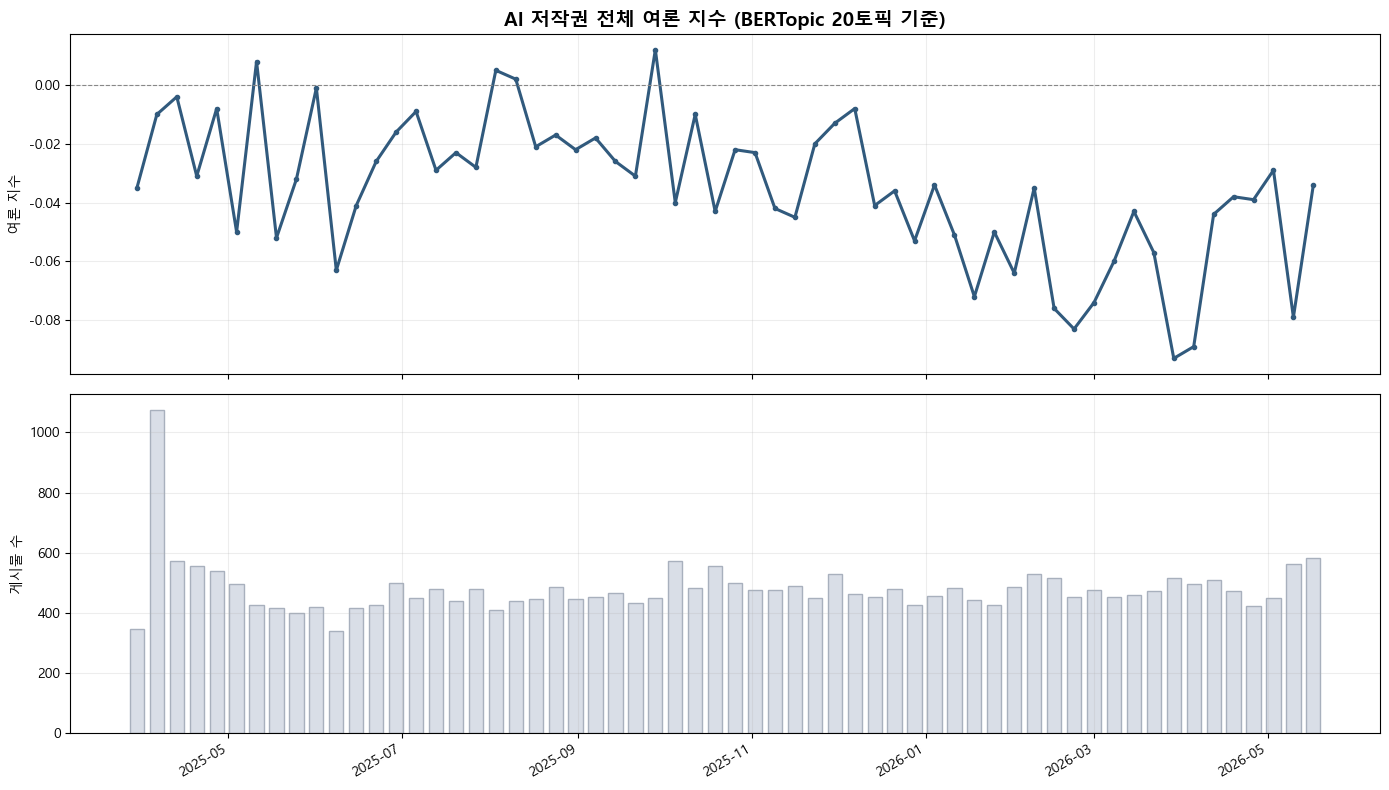

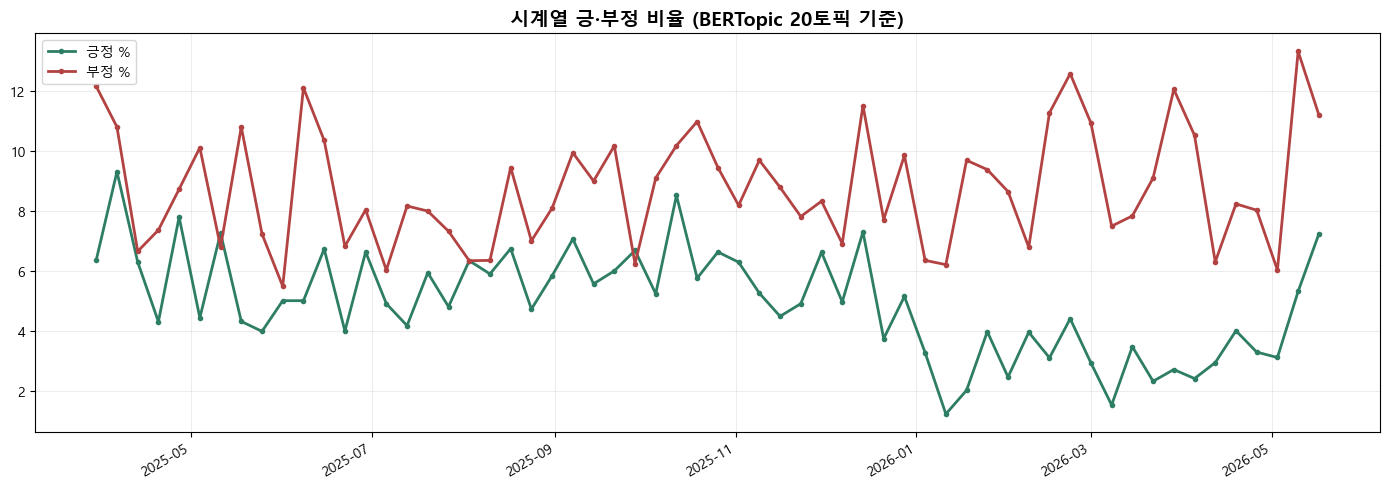

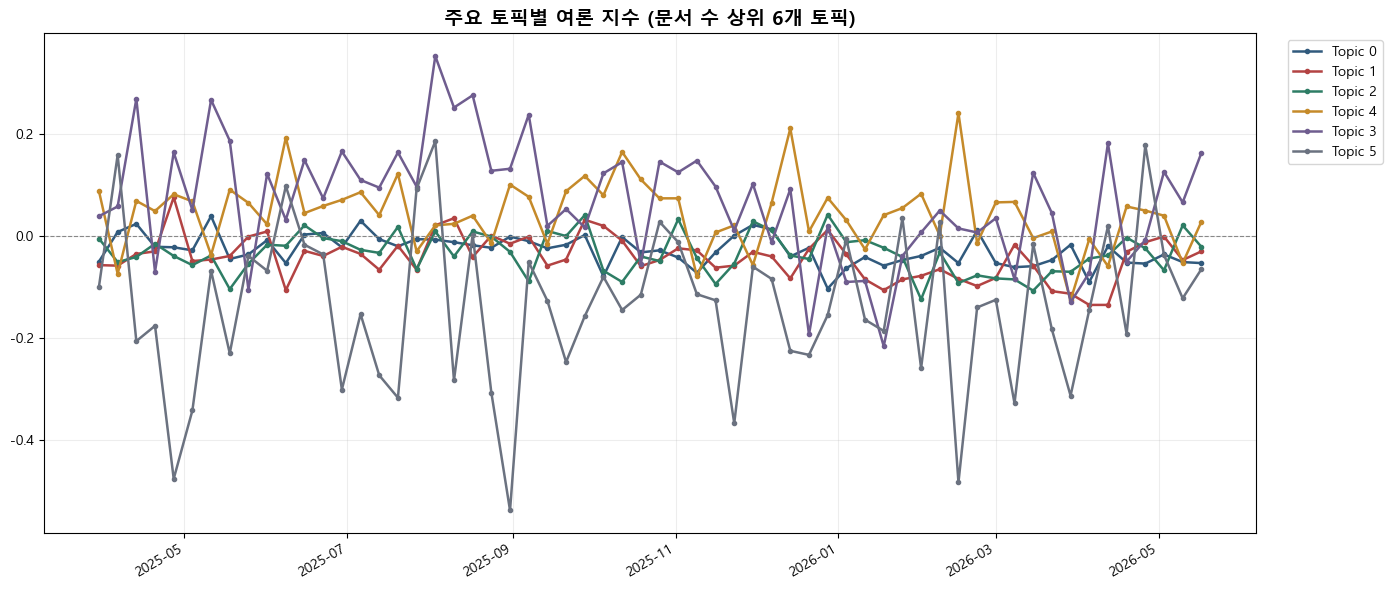

저장 완료: 시계열_전체_여론동향.csv, 시계열_토픽별_여론동향.csv, PNG 3종


In [ ]:
# -------------------------------------------------------------------------
# 시계열 감성분석
# -------------------------------------------------------------------------
# 작성날짜를 기준으로 문서를 주 단위로 묶고,
# 전체 여론지수와 긍정/부정 비율이 시간에 따라 어떻게 변하는지 확인합니다.
# 지브리풍 이미지 확산, 소송, 정책 논의 등 사건성 이슈와 연결해 해석합니다.

# =============================================================================
# [2] 시계열 여론 동향: 최신 BERTopic topic_num 기준
# =============================================================================
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

file_path = globals().get("file_path", r"C:\Users\WHKONG\AI 저작권 여론 분석")
RESULT_CSV = os.path.join(file_path, "딥러닝_감성분석_결과.csv")
FREQ = "W"

df = pd.read_csv(RESULT_CSV, encoding="utf-8-sig", dtype=object, engine="python", on_bad_lines="skip")
df["topic_num"] = pd.to_numeric(df["topic_num"], errors="coerce")
for col in ["dl_sentiment_score", "dl_prob_positive", "dl_prob_negative"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["topic_num", "dl_sentiment_score"]).copy()
df["topic_num"] = df["topic_num"].astype(int)

def parse_posted_at(s):
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    m = re.search(r"(\d{4})\.\s*(\d{1,2})\.\s*(\d{1,2})", s)
    if not m:
        return pd.NaT
    y, mo, d = map(int, m.groups())
    hm = re.search(r"(\d{1,2}):(\d{2})", s)
    if hm:
        hh, mm = map(int, hm.groups())
        return pd.Timestamp(y, mo, d, hh, mm)
    return pd.Timestamp(y, mo, d)

def pct(series, label):
    return round((series.astype(str).eq(label).mean() * 100), 2)

df["posted_at"] = df["작성날짜"].map(parse_posted_at)
ts = df.dropna(subset=["posted_at"]).copy().set_index("posted_at").sort_index()
print(f"날짜 파싱: {len(ts):,} / {len(df):,}건")

if {"dl_prob_positive", "dl_prob_negative"}.issubset(ts.columns):
    ts["opinion_index"] = ts["dl_prob_positive"] - ts["dl_prob_negative"]
else:
    ts["opinion_index"] = ts["dl_sentiment_score"]

overall = ts.resample(FREQ).agg(
    문서수=("opinion_index", "count"),
    여론지수=("opinion_index", "mean"),
    긍정비율=("dl_sentiment_label", lambda s: pct(s, "positive")),
    부정비율=("dl_sentiment_label", lambda s: pct(s, "negative")),
).round(3)
overall = overall[overall["문서수"] > 0]
overall.to_csv(os.path.join(file_path, "시계열_전체_여론동향.csv"), encoding="utf-8-sig")

parts = []
for topic in sorted(ts["topic_num"].unique()):
    sub = ts[ts["topic_num"] == topic].resample(FREQ).agg(
        여론지수=("opinion_index", "mean"),
        문서수=("opinion_index", "count"),
        긍정비율=("dl_sentiment_label", lambda s: pct(s, "positive")),
        부정비율=("dl_sentiment_label", lambda s: pct(s, "negative")),
    ).round(3)
    sub = sub[sub["문서수"] > 0]
    sub["topic_num"] = int(topic)
    parts.append(sub.reset_index())

topic_ts = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
topic_ts.to_csv(os.path.join(file_path, "시계열_토픽별_여론동향.csv"), index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(overall.index, overall["여론지수"], color="#315A7D", linewidth=2.2, marker="o", markersize=3)
axes[0].axhline(0, color="#888888", linestyle="--", linewidth=0.8)
axes[0].set_title("AI 저작권 전체 여론 지수 (BERTopic 20토픽 기준)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("여론 지수")
axes[0].grid(True, alpha=0.22)
axes[1].bar(overall.index, overall["문서수"], width=5, color="#D9DEE7", edgecolor="#A8B0BD")
axes[1].set_ylabel("게시물 수")
axes[1].grid(True, alpha=0.22)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(file_path, "시계열_전체_여론지수.png"), dpi=160, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(overall.index, overall["긍정비율"], color="#2E7D65", linewidth=2.0, marker="o", markersize=3, label="긍정 %")
ax2.plot(overall.index, overall["부정비율"], color="#B34343", linewidth=2.0, marker="o", markersize=3, label="부정 %")
ax2.set_title("시계열 긍·부정 비율 (BERTopic 20토픽 기준)", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.22)
fig2.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(file_path, "시계열_긍부정_비율.png"), dpi=160, bbox_inches="tight")
plt.show()

top_topics = df[df["topic_num"] != -1]["topic_num"].value_counts().head(6).index.tolist()
fig3, ax3 = plt.subplots(figsize=(14, 6))
palette = ["#315A7D", "#B34343", "#2E7D65", "#C58A2A", "#6F5D8F", "#6B7280"]
for color, topic in zip(palette, top_topics):
    sub = topic_ts[topic_ts["topic_num"] == topic]
    ax3.plot(sub["posted_at"], sub["여론지수"], marker="o", markersize=3, linewidth=1.8, label=f"Topic {topic}", color=color)
ax3.axhline(0, color="#888888", linestyle="--", linewidth=0.8)
ax3.set_title("주요 토픽별 여론 지수 (문서 수 상위 6개 토픽)", fontsize=14, fontweight="bold")
ax3.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax3.grid(True, alpha=0.22)
fig3.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(file_path, "시계열_토픽별_여론지수.png"), dpi=160, bbox_inches="tight")
plt.show()

print("저장 완료: 시계열_전체_여론동향.csv, 시계열_토픽별_여론동향.csv, PNG 3종")
